# Cross-Validation & Hyperparameter Tuning

## Welcome! What You'll Learn

By the end of this tutorial, you will understand:
- **What is cross-validation** and why it's important (think of it like testing a recipe multiple times)
- **How to make AI models better** by finding the right settings (like tuning a musical instrument)
- **Different ways to test your AI model** to make sure it works on new data
- **How to avoid common mistakes** that make models look better than they actually are

**No programming experience needed!** We'll explain everything step by step with real-world examples.

## Learning Objectives
- Master various cross-validation strategies for robust model evaluation
- Learn systematic hyperparameter tuning techniques  
- Understand advanced optimization methods (Grid Search, Random Search, Bayesian)
- Apply nested cross-validation for unbiased model selection

## 📖 Introduction: Why Do We Need This?

### The Problem

Imagine you're a teacher creating a test for your students. If you always give them the same questions they practiced with, they might do very well on that test but fail when faced with new questions. This is similar to what happens with AI models!

**In AI/Machine Learning:**
- We train a model on some data (like students studying from practice problems)
- We want to know if it will work well on NEW, unseen data (like the real test)
- If we only test it on data it has already seen, we can't trust the results!

### Two Big Questions This Tutorial Answers:

1. **Cross-Validation**: How do we test our model reliably to know it will work on new data?
2. **Hyperparameter Tuning**: How do we find the best settings to make our model perform its best?

### Real-World Analogy

Think of building a paper airplane:
- **The design** = Your AI model
- **How you fold it** = Your hyperparameters (settings)
- **Test flights** = Cross-validation (testing multiple times)
- **The goal** = Make it fly far on ANY flight, not just one lucky throw!

---

## Cross-Validation Fundamentals

**Purpose**: Obtain more robust performance estimates by using all data for both training and validation.

### What is Cross-Validation? (Simple Explanation)

Instead of testing your model once, you test it multiple times on different portions of your data. It's like:
- A chef tasting a soup at different spots in the pot (not just one spoonful)
- A teacher giving multiple quizzes instead of just one final exam
- Testing a car on different road conditions (city, highway, rain, etc.)

**Why is this better?**
- One test might be lucky or unlucky
- Multiple tests give a more reliable average
- You use ALL your data for both training and testing

![Train / Validation / Test Split](./figures/0_split.png)

### K-Fold Cross-Validation

<img src="./figures/K-FoldCV.png" alt="K-Fold" width="80%" />

**Simple Explanation:**
Imagine you have a deck of 100 cards (your data). In 5-Fold Cross-Validation:
1. **Shuffle and split** the deck into 5 equal piles (20 cards each)
2. **Round 1**: Use piles 1-4 to learn, test on pile 5
3. **Round 2**: Use piles 1-3 + pile 5 to learn, test on pile 4
4. **Round 3**: Use piles 1-2 + piles 4-5 to learn, test on pile 3
5. **Round 4**: Use piles 1 + piles 3-5 to learn, test on pile 2
6. **Round 5**: Use piles 2-5 to learn, test on pile 1
7. **Calculate average** of all 5 test scores

**Visual Representation:**
```
Fold 1: [TEST] [TRAIN] [TRAIN] [TRAIN] [TRAIN]
Fold 2: [TRAIN] [TEST] [TRAIN] [TRAIN] [TRAIN]
Fold 3: [TRAIN] [TRAIN] [TEST] [TRAIN] [TRAIN]
Fold 4: [TRAIN] [TRAIN] [TRAIN] [TEST] [TRAIN]
Fold 5: [TRAIN] [TRAIN] [TRAIN] [TRAIN] [TEST]
```

**The Process:**
1. **Split** data into k equal-sized folds (usually k=5 or k=10)
2. **Train** on k-1 folds, validate on the remaining fold
3. **Repeat** k times, each fold serves as validation once
4. **Average** performance across all folds

**Mathematical Formula:**

$$CV_k = \frac{1}{k}\sum_{i=1}^{k} L(f_i, D_i^{val})$$

Where:
- $CV_k$ = Cross-validation score
- $k$ = Number of folds
- $f_i$ = Model trained on all folds except fold $i$
- $D_i^{val}$ = Validation fold $i$
- $L$ = Loss/Error function



In [25]:
# ============================================================================
# IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Scikit-learn imports
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    GroupKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.datasets import (
    make_classification,
    make_regression,
    load_iris,
    load_wine,
    load_breast_cancer
)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score
)

from scipy.stats import randint, uniform

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("="*70)
print("Cross-Validation Examples - Ready to Run!")
print("="*70)

Cross-Validation Examples - Ready to Run!


In [2]:
# ============================================================================
# EXAMPLE 1: TRAIN-TEST SPLIT vs K-FOLD COMPARISON
# ============================================================================

def example_1_train_test_vs_kfold():
    """
    Compare single train-test split with K-Fold Cross-Validation

    Key Learning: K-Fold provides more reliable estimates
    """
    print("\n" + "="*70)
    print("EXAMPLE 1: Train-Test Split vs K-Fold Cross-Validation")
    print("="*70)

    # Generate dataset
    X, y = make_classification(
        n_samples=1000,
        n_features=20,
        n_informative=15,
        n_redundant=5,
        random_state=42
    )

    print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")

    # Method 1: Single Train-Test Split
    print("\n" + "-"*70)
    print("Method 1: Single Train-Test Split")
    print("-"*70)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    single_score = model.score(X_test, y_test)

    print(f"Training set size: {X_train.shape[0]}")
    print(f"Test set size: {X_test.shape[0]}")
    print(f"Accuracy: {single_score:.4f}")
    print("⚠️  Problem: Just ONE test - is this reliable?")

    # Method 2: 5-Fold Cross-Validation
    print("\n" + "-"*70)
    print("Method 2: 5-Fold Cross-Validation")
    print("-"*70)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=5)

    print(f"Fold 1: {cv_scores[0]:.4f}")
    print(f"Fold 2: {cv_scores[1]:.4f}")
    print(f"Fold 3: {cv_scores[2]:.4f}")
    print(f"Fold 4: {cv_scores[3]:.4f}")
    print(f"Fold 5: {cv_scores[4]:.4f}")
    print("-"*70)
    print(f"Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print("✅ Much more reliable estimate!")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Comparison
    methods = ['Single Split', '5-Fold CV (Mean)']
    scores = [single_score, cv_scores.mean()]
    errors = [0, cv_scores.std()]

    colors = ['#e74c3c', '#2ecc71']
    axes[0].bar(methods, scores, yerr=errors, capsize=10,
                color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Single Split vs K-Fold CV', fontsize=14, fontweight='bold')
    axes[0].set_ylim([0.8, 1.0])
    axes[0].grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, (score, error) in enumerate(zip(scores, errors)):
        axes[0].text(i, score + error + 0.01, f'{score:.3f}',
                    ha='center', va='bottom', fontweight='bold')

    # Plot 2: Individual fold scores
    fold_names = [f'Fold {i+1}' for i in range(5)]
    axes[1].bar(fold_names, cv_scores, color='#3498db', alpha=0.7,
               edgecolor='black', linewidth=2)
    axes[1].axhline(cv_scores.mean(), color='red', linestyle='--',
                   linewidth=2, label=f'Mean: {cv_scores.mean():.3f}')
    axes[1].axhline(cv_scores.mean() + cv_scores.std(), color='orange',
                   linestyle=':', linewidth=1.5, label=f'+1 Std')
    axes[1].axhline(cv_scores.mean() - cv_scores.std(), color='orange',
                   linestyle=':', linewidth=1.5, label=f'-1 Std')
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('5-Fold CV: Individual Fold Scores', fontsize=14, fontweight='bold')
    axes[1].set_ylim([0.8, 1.0])
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('example_1_comparison.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualization saved as 'example_1_comparison.png'")
    plt.show()

    return cv_scores


EXAMPLE 1: Train-Test Split vs K-Fold Cross-Validation
Dataset: 1000 samples, 20 features

----------------------------------------------------------------------
Method 1: Single Train-Test Split
----------------------------------------------------------------------
Training set size: 800
Test set size: 200
Accuracy: 0.9000
⚠️  Problem: Just ONE test - is this reliable?

----------------------------------------------------------------------
Method 2: 5-Fold Cross-Validation
----------------------------------------------------------------------
Fold 1: 0.9000
Fold 2: 0.9200
Fold 3: 0.9450
Fold 4: 0.9000
Fold 5: 0.9150
----------------------------------------------------------------------
Mean Accuracy: 0.9160 ± 0.0166
✅ Much more reliable estimate!

✅ Visualization saved as 'example_1_comparison.png'


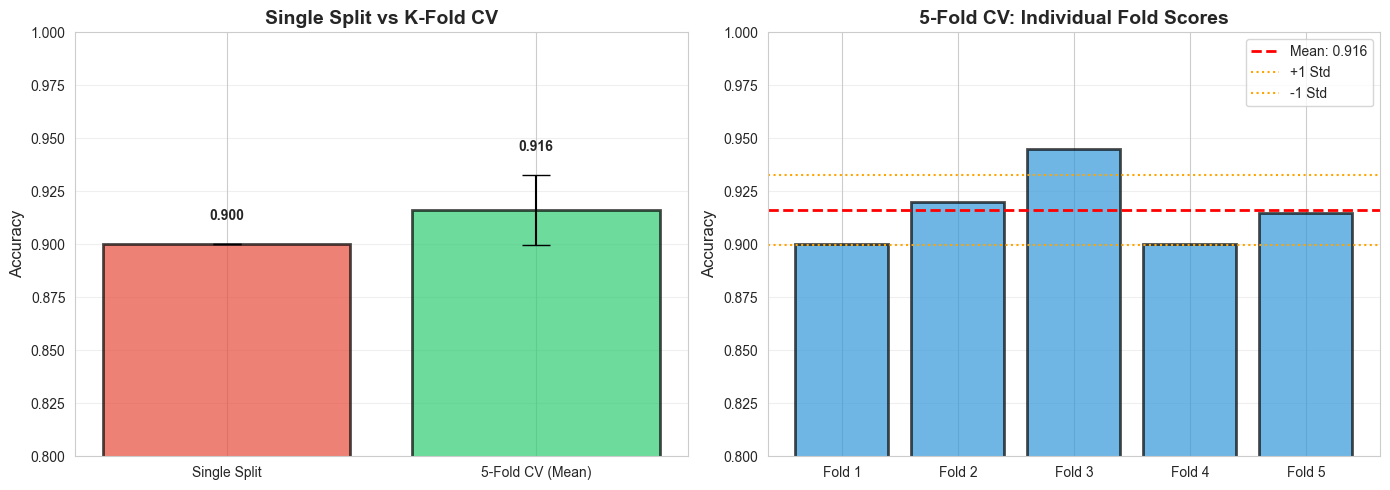

array([0.9  , 0.92 , 0.945, 0.9  , 0.915])

In [3]:
example_1_train_test_vs_kfold()

In [4]:
# ============================================================================
# EXAMPLE 2: K-FOLD CROSS-VALIDATION IN DETAIL
# ============================================================================

def example_2_kfold_detailed():
    """
    Detailed demonstration of K-Fold Cross-Validation mechanics

    Key Learning: How data is split in each fold
    """
    print("\n" + "="*70)
    print("EXAMPLE 2: K-Fold Cross-Validation - Detailed View")
    print("="*70)

    # Create small dataset for visualization
    X, y = make_classification(n_samples=100, n_features=10, random_state=42)

    print(f"Dataset: {X.shape[0]} samples")
    print(f"We'll use 5-fold CV (20 samples per fold)")

    # Create K-Fold splitter
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    # Visualize splits
    fig, axes = plt.subplots(5, 1, figsize=(12, 8))

    fold_scores = []
    model = RandomForestClassifier(n_estimators=50, random_state=42)

    for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(X)):
        # Train and evaluate
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]

        model.fit(X_train_fold, y_train_fold)
        score = model.score(X_test_fold, y_test_fold)
        fold_scores.append(score)

        print(f"\nFold {fold_idx + 1}:")
        print(f"  Train indices: {len(train_idx)} samples (indices {train_idx[:5]}...{train_idx[-5:]})")
        print(f"  Test indices:  {len(test_idx)} samples (indices {test_idx[:5]}...{test_idx[-5:]})")
        print(f"  Accuracy: {score:.4f}")

        # Visualize
        all_indices = np.arange(100)
        colors = ['#3498db' if i in train_idx else '#e74c3c' for i in all_indices]

        axes[fold_idx].scatter(all_indices, [fold_idx]*100, c=colors,
                              s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
        axes[fold_idx].set_xlim(-5, 105)
        axes[fold_idx].set_ylim(fold_idx - 0.5, fold_idx + 0.5)
        axes[fold_idx].set_ylabel(f'Fold {fold_idx + 1}\n{score:.3f}',
                                 fontweight='bold', fontsize=10)
        axes[fold_idx].set_yticks([])
        axes[fold_idx].grid(axis='x', alpha=0.3)

        if fold_idx == 0:
            # Add legend
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='#3498db', edgecolor='black', label='Train'),
                Patch(facecolor='#e74c3c', edgecolor='black', label='Test')
            ]
            axes[fold_idx].legend(handles=legend_elements, loc='upper right')

        if fold_idx == 4:
            axes[fold_idx].set_xlabel('Sample Index', fontsize=12)

    plt.suptitle('K-Fold Cross-Validation: How Data is Split',
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('example_2_kfold_visualization.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualization saved as 'example_2_kfold_visualization.png'")
    plt.show()

    print("\n" + "-"*70)
    print(f"Final Result: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
    print("-"*70)

    return fold_scores


EXAMPLE 2: K-Fold Cross-Validation - Detailed View
Dataset: 100 samples
We'll use 5-fold CV (20 samples per fold)

Fold 1:
  Train indices: 80 samples (indices [1 2 3 5 6]...[95 96 97 98 99])
  Test indices:  20 samples (indices [ 0  4 10 12 18]...[76 77 80 83 90])
  Accuracy: 1.0000

Fold 2:
  Train indices: 80 samples (indices [0 1 2 3 4]...[94 95 97 98 99])
  Test indices:  20 samples (indices [ 5  9 11 15 16]...[72 85 88 93 96])
  Accuracy: 0.8500

Fold 3:
  Train indices: 80 samples (indices [0 1 2 4 5]...[94 96 97 98 99])
  Test indices:  20 samples (indices [ 3  6  7  8 13]...[64 78 81 89 95])
  Accuracy: 0.9000

Fold 4:
  Train indices: 80 samples (indices [0 1 2 3 4]...[91 92 93 95 96])
  Test indices:  20 samples (indices [32 41 43 46 48]...[79 94 97 98 99])
  Accuracy: 0.9500

Fold 5:
  Train indices: 80 samples (indices [0 3 4 5 6]...[95 96 97 98 99])
  Test indices:  20 samples (indices [ 1  2 14 20 21]...[84 86 87 91 92])
  Accuracy: 0.9500

✅ Visualization saved as 'exa

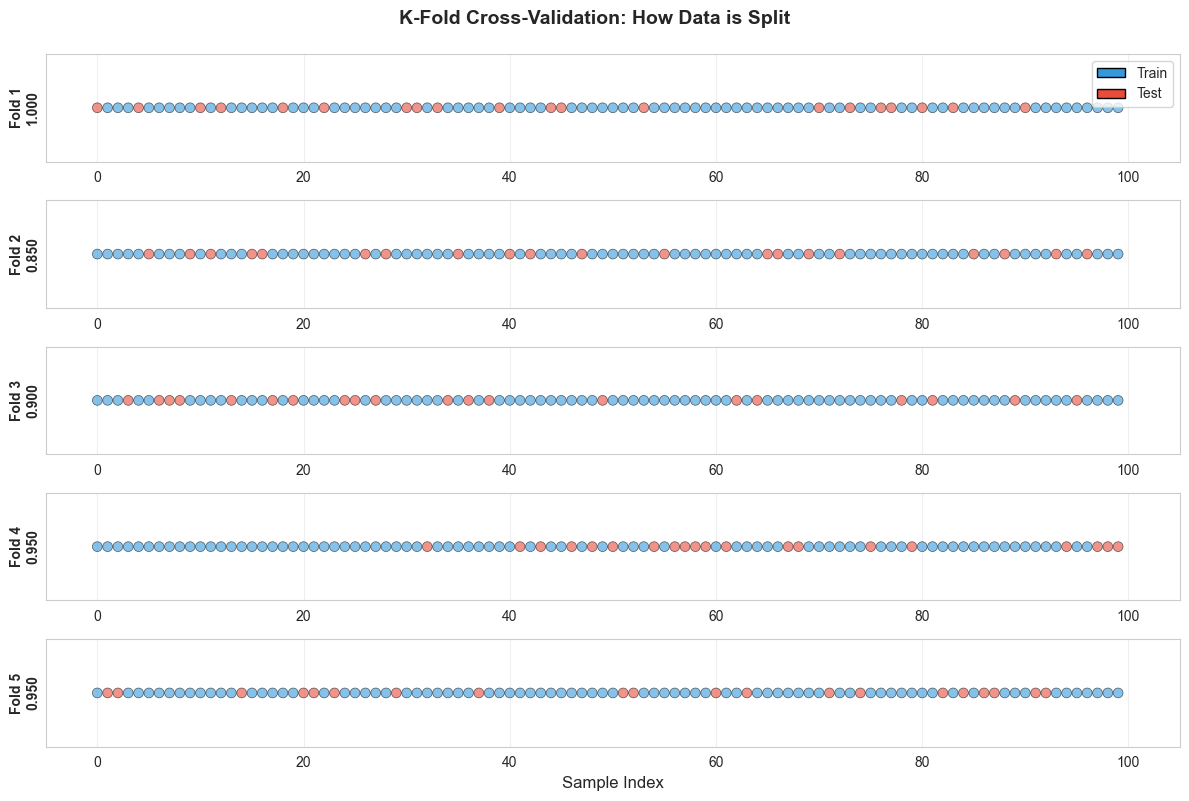


----------------------------------------------------------------------
Final Result: 0.9300 ± 0.0510
----------------------------------------------------------------------


[1.0, 0.85, 0.9, 0.95, 0.95]

In [5]:
example_2_kfold_detailed()

## Cross-Validation Strategies

### Stratified K-Fold
**Use Case**: Classification with imbalanced classes

**Method**: Maintains class proportions in each fold

**Advantage**: More representative splits for skewed datasets

![Stratified K-Fold](./figures/Stratified_K-Fold.png)

In [6]:
# ============================================================================
# EXAMPLE 3: STRATIFIED K-FOLD (IMBALANCED DATA)
# ============================================================================

def example_3_stratified_kfold():
    """
    Demonstrate Stratified K-Fold for imbalanced datasets

    Key Learning: Maintains class distribution in each fold
    """
    print("\n" + "="*70)
    print("EXAMPLE 3: Stratified K-Fold for Imbalanced Data")
    print("="*70)

    # Create imbalanced dataset (95% class 0, 5% class 1)
    X, y = make_classification(
        n_samples=1000,
        n_features=20,
        n_classes=2,
        weights=[0.95, 0.05],  # Imbalanced!
        flip_y=0.01,
        random_state=42
    )

    print(f"Dataset: {X.shape[0]} samples")
    print(f"Class distribution:")
    unique, counts = np.unique(y, return_counts=True)
    for cls, count in zip(unique, counts):
        print(f"  Class {cls}: {count} samples ({count/len(y)*100:.1f}%)")

    # Compare Regular K-Fold vs Stratified K-Fold
    print("\n" + "-"*70)
    print("Comparison: Regular K-Fold vs Stratified K-Fold")
    print("-"*70)

    # Regular K-Fold
    print("\nRegular K-Fold (may have uneven distribution):")
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    regular_distributions = []
    for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(X, y)):
        y_test_fold = y[test_idx]
        n_minority = np.sum(y_test_fold == 1)
        pct_minority = n_minority / len(y_test_fold) * 100
        regular_distributions.append(pct_minority)
        print(f"  Fold {fold_idx + 1}: {n_minority} minority samples ({pct_minority:.1f}%)")

    # Stratified K-Fold
    print("\nStratified K-Fold (maintains 5% ratio):")
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    stratified_distributions = []
    for fold_idx, (train_idx, test_idx) in enumerate(stratified_kfold.split(X, y)):
        y_test_fold = y[test_idx]
        n_minority = np.sum(y_test_fold == 1)
        pct_minority = n_minority / len(y_test_fold) * 100
        stratified_distributions.append(pct_minority)
        print(f"  Fold {fold_idx + 1}: {n_minority} minority samples ({pct_minority:.1f}%)")

    # Evaluate model performance
    model = RandomForestClassifier(n_estimators=100, random_state=42,
                                   class_weight='balanced')

    print("\n" + "-"*70)
    print("Model Performance Comparison")
    print("-"*70)

    # Regular K-Fold scores
    regular_scores = cross_val_score(model, X, y, cv=kfold, scoring='f1')
    print(f"\nRegular K-Fold F1 Score: {regular_scores.mean():.4f} ± {regular_scores.std():.4f}")

    # Stratified K-Fold scores
    stratified_scores = cross_val_score(model, X, y, cv=stratified_kfold, scoring='f1')
    print(f"Stratified K-Fold F1 Score: {stratified_scores.mean():.4f} ± {stratified_scores.std():.4f}")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Class distribution in folds
    x = np.arange(5)
    width = 0.35

    axes[0].bar(x - width/2, regular_distributions, width,
               label='Regular K-Fold', color='#e74c3c', alpha=0.7,
               edgecolor='black', linewidth=1.5)
    axes[0].bar(x + width/2, stratified_distributions, width,
               label='Stratified K-Fold', color='#2ecc71', alpha=0.7,
               edgecolor='black', linewidth=1.5)
    axes[0].axhline(5.0, color='blue', linestyle='--', linewidth=2,
                   label='Expected (5%)')
    axes[0].set_xlabel('Fold', fontsize=12)
    axes[0].set_ylabel('Minority Class %', fontsize=12)
    axes[0].set_title('Class Distribution Across Folds', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'Fold {i+1}' for i in range(5)])
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Plot 2: F1 Score comparison
    fold_names = [f'Fold {i+1}' for i in range(5)]
    x = np.arange(5)

    axes[1].plot(x, regular_scores, 'o-', linewidth=2, markersize=8,
                label=f'Regular ({regular_scores.mean():.3f} ± {regular_scores.std():.3f})',
                color='#e74c3c')
    axes[1].plot(x, stratified_scores, 's-', linewidth=2, markersize=8,
                label=f'Stratified ({stratified_scores.mean():.3f} ± {stratified_scores.std():.3f})',
                color='#2ecc71')
    axes[1].set_xlabel('Fold', fontsize=12)
    axes[1].set_ylabel('F1 Score', fontsize=12)
    axes[1].set_title('Model Performance: Regular vs Stratified',
                     fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(fold_names)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('example_3_stratified_comparison.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualization saved as 'example_3_stratified_comparison.png'")
    plt.show()

    print("\n💡 Key Takeaway: For imbalanced data, always use StratifiedKFold!")

    return stratified_scores


EXAMPLE 3: Stratified K-Fold for Imbalanced Data
Dataset: 1000 samples
Class distribution:
  Class 0: 947 samples (94.7%)
  Class 1: 53 samples (5.3%)

----------------------------------------------------------------------
Comparison: Regular K-Fold vs Stratified K-Fold
----------------------------------------------------------------------

Regular K-Fold (may have uneven distribution):
  Fold 1: 11 minority samples (5.5%)
  Fold 2: 10 minority samples (5.0%)
  Fold 3: 7 minority samples (3.5%)
  Fold 4: 17 minority samples (8.5%)
  Fold 5: 8 minority samples (4.0%)

Stratified K-Fold (maintains 5% ratio):
  Fold 1: 10 minority samples (5.0%)
  Fold 2: 10 minority samples (5.0%)
  Fold 3: 11 minority samples (5.5%)
  Fold 4: 11 minority samples (5.5%)
  Fold 5: 11 minority samples (5.5%)

----------------------------------------------------------------------
Model Performance Comparison
----------------------------------------------------------------------

Regular K-Fold F1 Score: 0.

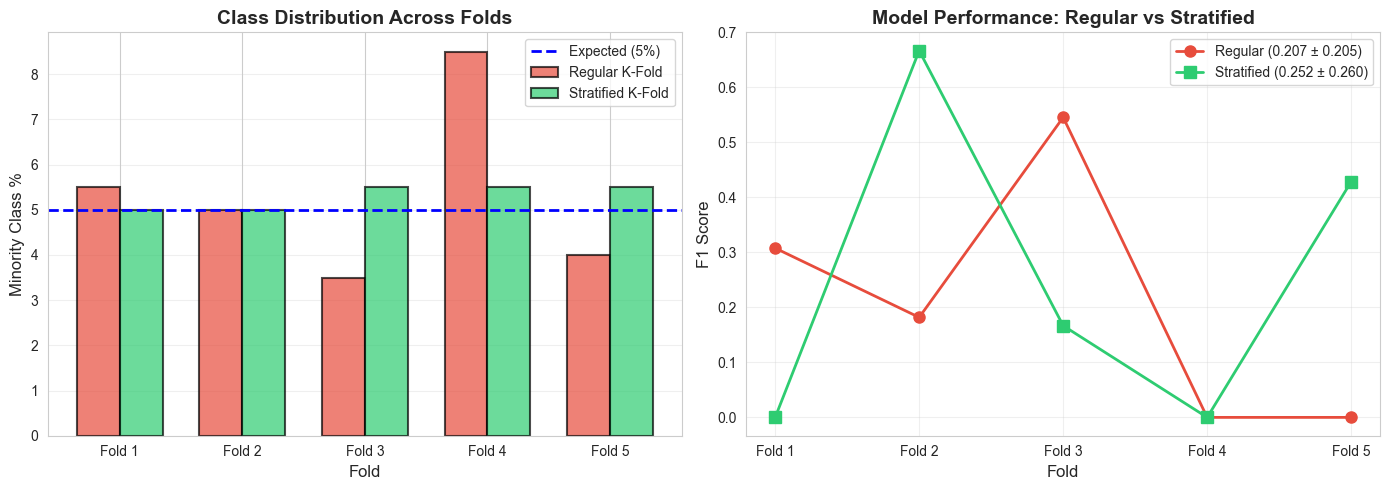


💡 Key Takeaway: For imbalanced data, always use StratifiedKFold!


array([0.        , 0.66666667, 0.16666667, 0.        , 0.42857143])

In [7]:
example_3_stratified_kfold()

### Leave-One-Out CV (LOOCV)
**Method**: k = n (number of samples)

**Advantage**: Maximum use of training data

**Disadvantage**: Computationally expensive, high variance estimates

![Leave-One-Out](./figures/LOOV.png)

In [8]:
# ============================================================================
# EXAMPLE 4: LEAVE-ONE-OUT CROSS-VALIDATION
# ============================================================================

def example_4_leave_one_out():
    """
    Demonstrate Leave-One-Out Cross-Validation for small datasets

    Key Learning: Maximum data usage but computationally expensive
    """
    print("\n" + "="*70)
    print("EXAMPLE 4: Leave-One-Out Cross-Validation (LOOCV)")
    print("="*70)

    # Create small dataset (common scenario for LOOCV)
    X, y = make_classification(
        n_samples=50,  # Small dataset!
        n_features=10,
        n_informative=8,
        n_redundant=2,
        random_state=42
    )

    print(f"Dataset: {X.shape[0]} samples (small dataset scenario)")
    print(f"LOOCV will perform {X.shape[0]} training runs!")

    # Create LOOCV splitter
    loo = LeaveOneOut()

    print(f"\nNumber of folds: {loo.get_n_splits(X)}")
    print("Each fold: Train on 49 samples, test on 1 sample")

    # Compare with K-Fold
    import time

    model = RandomForestClassifier(n_estimators=50, random_state=42)

    # K-Fold CV (k=5)
    print("\n" + "-"*70)
    print("Method 1: 5-Fold Cross-Validation")
    print("-"*70)
    start_time = time.time()
    kfold_scores = cross_val_score(model, X, y, cv=5)
    kfold_time = time.time() - start_time
    print(f"Time: {kfold_time:.3f} seconds")
    print(f"Mean Accuracy: {kfold_scores.mean():.4f} ± {kfold_scores.std():.4f}")

    # LOOCV
    print("\n" + "-"*70)
    print("Method 2: Leave-One-Out Cross-Validation")
    print("-"*70)
    start_time = time.time()
    loo_scores = cross_val_score(model, X, y, cv=loo)
    loo_time = time.time() - start_time
    print(f"Time: {loo_time:.3f} seconds ({loo_time/kfold_time:.1f}x slower)")
    print(f"Mean Accuracy: {loo_scores.mean():.4f} ± {loo_scores.std():.4f}")
    print(f"Individual predictions: {loo_scores[:10]}... (showing first 10)")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Score distribution
    axes[0, 0].hist(kfold_scores, bins=5, alpha=0.7, color='#3498db',
                   edgecolor='black', linewidth=1.5, label='5-Fold CV')
    axes[0, 0].axvline(kfold_scores.mean(), color='blue', linestyle='--',
                      linewidth=2, label=f'Mean: {kfold_scores.mean():.3f}')
    axes[0, 0].set_xlabel('Accuracy', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('5-Fold CV Score Distribution',
                        fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].hist(loo_scores, bins=20, alpha=0.7, color='#2ecc71',
                   edgecolor='black', linewidth=1.5, label='LOOCV')
    axes[0, 1].axvline(loo_scores.mean(), color='green', linestyle='--',
                      linewidth=2, label=f'Mean: {loo_scores.mean():.3f}')
    axes[0, 1].set_xlabel('Accuracy (0 or 1)', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('LOOCV Score Distribution',
                        fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Plot 2: Comparison
    methods = ['5-Fold CV', 'LOOCV']
    means = [kfold_scores.mean(), loo_scores.mean()]
    stds = [kfold_scores.std(), loo_scores.std()]
    times = [kfold_time, loo_time]

    axes[1, 0].bar(methods, means, yerr=stds, capsize=10,
                  color=['#3498db', '#2ecc71'], alpha=0.7,
                  edgecolor='black', linewidth=2)
    axes[1, 0].set_ylabel('Accuracy', fontsize=12)
    axes[1, 0].set_title('Performance Comparison',
                        fontsize=14, fontweight='bold')
    axes[1, 0].set_ylim([0.7, 1.0])
    axes[1, 0].grid(axis='y', alpha=0.3)

    for i, (mean, std) in enumerate(zip(means, stds)):
        axes[1, 0].text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}',
                       ha='center', fontweight='bold')

    axes[1, 1].bar(methods, times, color=['#3498db', '#2ecc71'], alpha=0.7,
                  edgecolor='black', linewidth=2)
    axes[1, 1].set_ylabel('Time (seconds)', fontsize=12)
    axes[1, 1].set_title('Computation Time', fontsize=14, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

    for i, time_val in enumerate(times):
        axes[1, 1].text(i, time_val + 0.01, f'{time_val:.3f}s',
                       ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('example_4_loocv_comparison.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualization saved as 'example_4_loocv_comparison.png'")
    plt.show()

    print("\n" + "-"*70)
    print("Pros of LOOCV:")
    print("  ✅ Maximum data for training (N-1 samples)")
    print("  ✅ No randomness - deterministic")
    print("  ✅ Nearly unbiased estimate")
    print("\nCons of LOOCV:")
    print(f"  ❌ Very slow ({loo_time/kfold_time:.1f}x slower than 5-fold)")
    print("  ❌ High variance in estimates")
    print("  ❌ Only practical for small datasets")
    print("-"*70)

    return loo_scores


EXAMPLE 4: Leave-One-Out Cross-Validation (LOOCV)
Dataset: 50 samples (small dataset scenario)
LOOCV will perform 50 training runs!

Number of folds: 50
Each fold: Train on 49 samples, test on 1 sample

----------------------------------------------------------------------
Method 1: 5-Fold Cross-Validation
----------------------------------------------------------------------
Time: 0.146 seconds
Mean Accuracy: 0.7400 ± 0.0800

----------------------------------------------------------------------
Method 2: Leave-One-Out Cross-Validation
----------------------------------------------------------------------
Time: 0.994 seconds (6.8x slower)
Mean Accuracy: 0.8000 ± 0.4000
Individual predictions: [0. 1. 1. 1. 1. 1. 1. 1. 1. 0.]... (showing first 10)

✅ Visualization saved as 'example_4_loocv_comparison.png'


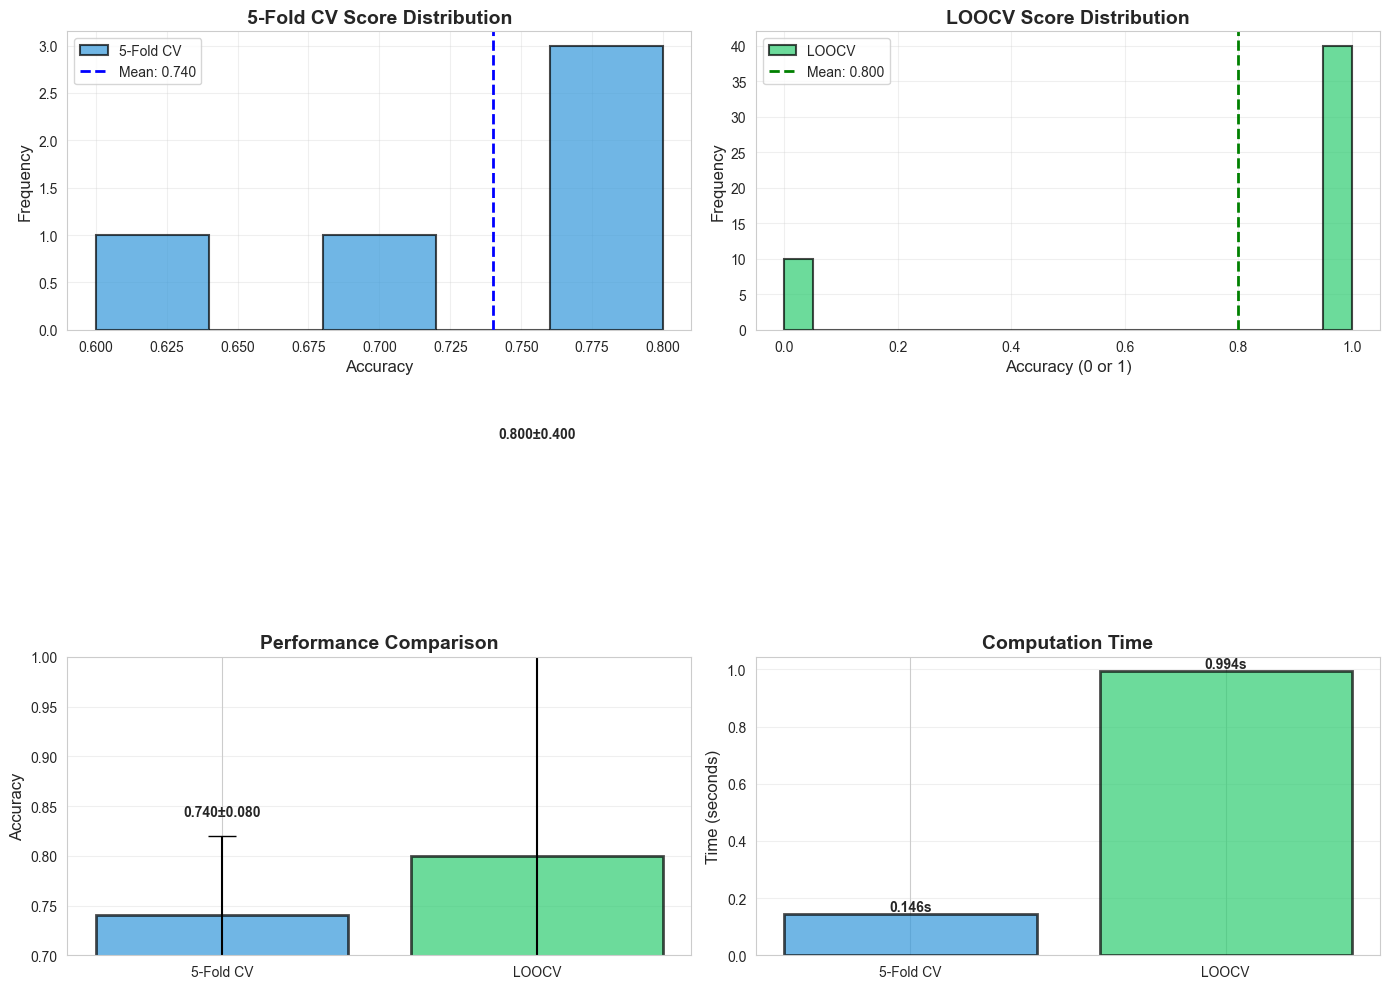


----------------------------------------------------------------------
Pros of LOOCV:
  ✅ Maximum data for training (N-1 samples)
  ✅ No randomness - deterministic
  ✅ Nearly unbiased estimate

Cons of LOOCV:
  ❌ Very slow (6.8x slower than 5-fold)
  ❌ High variance in estimates
  ❌ Only practical for small datasets
----------------------------------------------------------------------


array([0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.])

In [9]:
example_4_leave_one_out()

### Time Series CV
**Use Case**: Temporal data where order matters

**Method**: Train on past, validate on future (expanding/sliding window)

**Key**: Respects temporal ordering to avoid data leakage

![Time_Series](./figures/Time_Series.png)

In [10]:
# ============================================================================
# EXAMPLE 5: TIME SERIES CROSS-VALIDATION
# ============================================================================

def example_5_time_series_cv():
    """
    Demonstrate Time Series Cross-Validation

    Key Learning: Respects temporal order - always train on past, test on future
    """
    print("\n" + "="*70)
    print("EXAMPLE 5: Time Series Cross-Validation")
    print("="*70)

    # Generate time series data
    n_samples = 365  # One year of daily data
    dates = pd.date_range('2020-01-01', periods=n_samples, freq='D')

    # Create synthetic stock price-like data
    np.random.seed(42)
    trend = np.linspace(100, 150, n_samples)
    seasonality = 10 * np.sin(2 * np.pi * np.arange(n_samples) / 365)
    noise = np.random.randn(n_samples) * 5
    prices = trend + seasonality + noise

    # Create features (simple: last 5 days)
    X_ts = []
    y_ts = []
    for i in range(5, len(prices)):
        X_ts.append(prices[i-5:i])  # Last 5 days
        y_ts.append(prices[i])       # Next day

    X_ts = np.array(X_ts)
    y_ts = np.array(y_ts)

    print(f"Time series: {len(dates)} days")
    print(f"Features: {X_ts.shape[0]} samples, {X_ts.shape[1]} features (last 5 days)")
    print(f"Task: Predict next day's price")

    # WARNING: Wrong approach
    print("\n" + "-"*70)
    print("❌ WRONG: Regular K-Fold (breaks time order!)")
    print("-"*70)

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    model = RandomForestRegressor(n_estimators=50, random_state=42)

    wrong_scores = cross_val_score(model, X_ts, y_ts, cv=kfold,
                                   scoring='r2')
    print(f"R² Score (MISLEADING): {wrong_scores.mean():.4f} ± {wrong_scores.std():.4f}")
    print("⚠️  This uses future data to predict the past - data leakage!")

    # CORRECT: Time Series Split
    print("\n" + "-"*70)
    print("✅ CORRECT: Time Series Split")
    print("-"*70)

    tscv = TimeSeriesSplit(n_splits=5)

    print("Split structure:")
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_ts)):
        train_start = dates[train_idx[0] + 5]
        train_end = dates[train_idx[-1] + 5]
        test_start = dates[test_idx[0] + 5]
        test_end = dates[test_idx[-1] + 5]

        print(f"\nFold {fold_idx + 1}:")
        print(f"  Train: {train_start.date()} to {train_end.date()} ({len(train_idx)} samples)")
        print(f"  Test:  {test_start.date()} to {test_end.date()} ({len(test_idx)} samples)")

    correct_scores = cross_val_score(model, X_ts, y_ts, cv=tscv,
                                    scoring='r2')
    print("\n" + "-"*70)
    print(f"R² Score (HONEST): {correct_scores.mean():.4f} ± {correct_scores.std():.4f}")
    print("✅ Always trains on past, tests on future")
    print("-"*70)

    # Visualization
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Plot 1: Original time series
    axes[0].plot(dates, prices, linewidth=2, color='#3498db')
    axes[0].set_xlabel('Date', fontsize=12)
    axes[0].set_ylabel('Price', fontsize=12)
    axes[0].set_title('Stock Price Time Series', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3)

    # Plot 2: Time Series Split visualization
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_ts)):
        # Adjust indices to match dates
        train_dates = dates[train_idx + 5]
        test_dates = dates[test_idx + 5]

        axes[1].scatter(train_dates, [fold_idx]*len(train_dates),
                       c='#3498db', s=10, alpha=0.6, label='Train' if fold_idx == 0 else '')
        axes[1].scatter(test_dates, [fold_idx]*len(test_dates),
                       c='#e74c3c', s=10, alpha=0.6, label='Test' if fold_idx == 0 else '')

    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].set_ylabel('Fold', fontsize=12)
    axes[1].set_title('Time Series Split: Train-Test Distribution',
                     fontsize=14, fontweight='bold')
    axes[1].set_yticks(range(5))
    axes[1].set_yticklabels([f'Fold {i+1}' for i in range(5)])
    axes[1].legend(loc='upper left')
    axes[1].grid(alpha=0.3)

    # Plot 3: Performance comparison
    fold_names = [f'Fold {i+1}' for i in range(5)]
    x = np.arange(5)

    axes[2].plot(x, wrong_scores, 'o-', linewidth=2, markersize=10,
                label=f'❌ Wrong (K-Fold): {wrong_scores.mean():.3f}',
                color='#e74c3c')
    axes[2].plot(x, correct_scores, 's-', linewidth=2, markersize=10,
                label=f'✅ Correct (TS Split): {correct_scores.mean():.3f}',
                color='#2ecc71')
    axes[2].set_xlabel('Fold', fontsize=12)
    axes[2].set_ylabel('R² Score', fontsize=12)
    axes[2].set_title('Performance: Wrong vs Correct Approach',
                     fontsize=14, fontweight='bold')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(fold_names)
    axes[2].legend(fontsize=11)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('example_5_time_series_cv.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualization saved as 'example_5_time_series_cv.png'")
    plt.show()

    print("\n💡 Key Takeaway: For time series data, ALWAYS use TimeSeriesSplit!")

    return correct_scores


EXAMPLE 5: Time Series Cross-Validation
Time series: 365 days
Features: 360 samples, 5 features (last 5 days)
Task: Predict next day's price

----------------------------------------------------------------------
❌ WRONG: Regular K-Fold (breaks time order!)
----------------------------------------------------------------------
R² Score (MISLEADING): 0.7258 ± 0.0476
⚠️  This uses future data to predict the past - data leakage!

----------------------------------------------------------------------
✅ CORRECT: Time Series Split
----------------------------------------------------------------------
Split structure:

Fold 1:
  Train: 2020-01-06 to 2020-03-05 (60 samples)
  Test:  2020-03-06 to 2020-05-04 (60 samples)

Fold 2:
  Train: 2020-01-06 to 2020-05-04 (120 samples)
  Test:  2020-05-05 to 2020-07-03 (60 samples)

Fold 3:
  Train: 2020-01-06 to 2020-07-03 (180 samples)
  Test:  2020-07-04 to 2020-09-01 (60 samples)

Fold 4:
  Train: 2020-01-06 to 2020-09-01 (240 samples)
  Test:  202

/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/3837838472.py:127: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/3837838472.py:127: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/3837838472.py:128: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.savefig('example_5_time_series_cv.png', dpi=150, bbox_inches='tight')
/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/3837838472.py:128: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('example_5_time_series_cv.png', dpi=150, bbox_inches='tight')



✅ Visualization saved as 'example_5_time_series_cv.png'


/Users/xiaotingzhou/miniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/xiaotingzhou/miniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


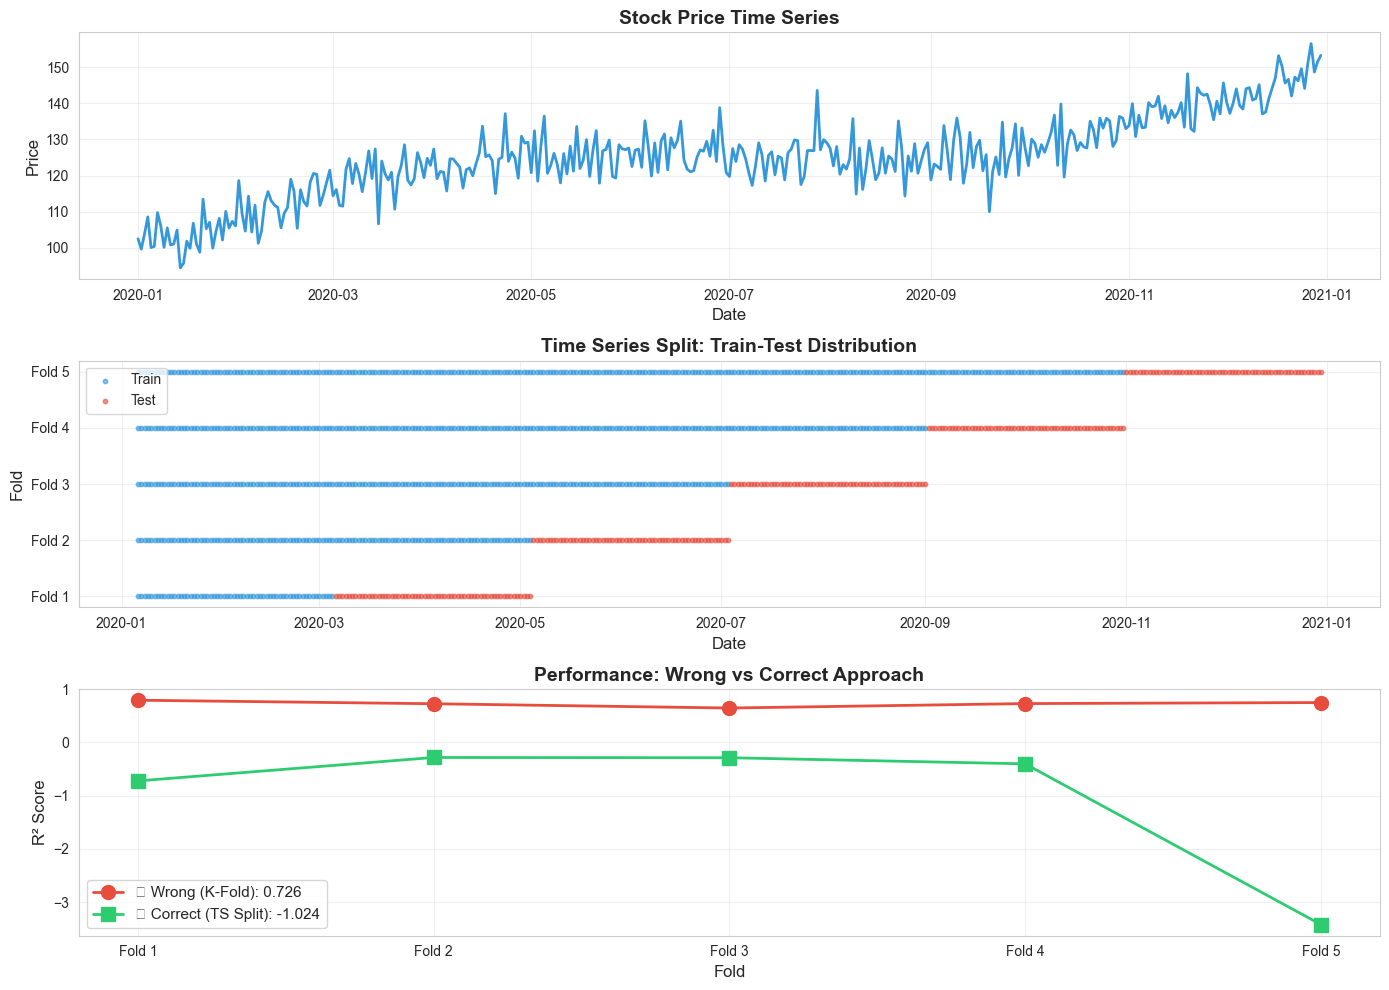


💡 Key Takeaway: For time series data, ALWAYS use TimeSeriesSplit!


array([-0.72356714, -0.28449567, -0.28902586, -0.40415035, -3.41770435])

In [11]:
example_5_time_series_cv()

### Group K-Fold Cross-Validation
**Use Case**: Grouped/clustered data with multiple samples per entity
  - Medical: Multiple scans per patient
  - Finance: Multiple transactions per customer
  - Research: Multiple measurements per subject
  - IoT: Multiple readings per device

**Method**: Group-based splitting
  - Identify groups (e.g., patient IDs, user IDs)
  - Split by groups, not individual samples
  - All samples from Group A → Training OR Validation (never both)
  - Maintains data independence between folds

**Advantage**: Prevents group leakage—the model cannot memorize specific groups during training and see them again during
  validation, ensuring true generalization to new, unseen groups

In [12]:
# ============================================================================
# EXAMPLE 6: GROUP K-FOLD CROSS-VALIDATION
# ============================================================================

def example_6_group_kfold():
    """
    Demonstrate Group K-Fold for preventing data leakage in grouped data

    Key Learning: Same group never appears in both train and test
    """
    print("\n" + "="*70)
    print("EXAMPLE 6: Group K-Fold Cross-Validation")
    print("="*70)

    # Simulate medical data: multiple scans per patient
    n_patients = 20
    scans_per_patient = np.random.randint(3, 8, size=n_patients)

    # Generate data
    X_list = []
    y_list = []
    groups = []

    for patient_id in range(n_patients):
        n_scans = scans_per_patient[patient_id]

        # Each patient has inherent characteristics (simulated)
        patient_baseline = np.random.randn(10)

        for scan in range(n_scans):
            # Scan = patient baseline + scan-specific noise
            scan_features = patient_baseline + np.random.randn(10) * 0.3
            X_list.append(scan_features)

            # Label (healthy=0 or sick=1) - correlated with patient baseline
            y_list.append(1 if patient_baseline.mean() > 0 else 0)

            # Group identifier
            groups.append(patient_id)

    X_grp = np.array(X_list)
    y_grp = np.array(y_list)
    groups = np.array(groups)

    print(f"Dataset: {len(X_grp)} scans from {n_patients} patients")
    print(f"Scans per patient: min={scans_per_patient.min()}, "
          f"max={scans_per_patient.max()}, mean={scans_per_patient.mean():.1f}")

    # Show patient distribution
    print("\nPatient distribution:")
    for patient_id in range(min(5, n_patients)):  # Show first 5
        patient_scans = np.sum(groups == patient_id)
        patient_label = y_grp[groups == patient_id][0]
        print(f"  Patient {patient_id}: {patient_scans} scans, "
              f"label={'Sick' if patient_label == 1 else 'Healthy'}")
    print("  ...")

    # WARNING: Wrong approach (regular K-Fold)
    print("\n" + "-"*70)
    print("❌ WRONG: Regular K-Fold (patient leakage!)")
    print("-"*70)

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    model = RandomForestClassifier(n_estimators=50, random_state=42)

    # Check for patient leakage
    for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(X_grp)):
        train_patients = set(groups[train_idx])
        test_patients = set(groups[test_idx])
        leaked_patients = train_patients.intersection(test_patients)

        if fold_idx == 0:  # Show first fold
            print(f"\nFold {fold_idx + 1}:")
            print(f"  Patients in train: {sorted(train_patients)[:5]}...")
            print(f"  Patients in test:  {sorted(test_patients)[:5]}...")
            print(f"  ⚠️  Leaked patients: {len(leaked_patients)} patients appear in BOTH!")
            if leaked_patients:
                print(f"     Examples: {sorted(leaked_patients)[:3]}")

    wrong_scores = cross_val_score(model, X_grp, y_grp, cv=kfold)
    print(f"\nAccuracy (MISLEADING): {wrong_scores.mean():.4f} ± {wrong_scores.std():.4f}")
    print("⚠️  Model might just memorize patients, not learn general patterns!")

    # CORRECT: Group K-Fold
    print("\n" + "-"*70)
    print("✅ CORRECT: Group K-Fold")
    print("-"*70)

    group_kfold = GroupKFold(n_splits=5)

    # Verify no leakage
    for fold_idx, (train_idx, test_idx) in enumerate(group_kfold.split(X_grp, y_grp, groups)):
        train_patients = set(groups[train_idx])
        test_patients = set(groups[test_idx])
        leaked_patients = train_patients.intersection(test_patients)

        if fold_idx == 0:  # Show first fold
            print(f"\nFold {fold_idx + 1}:")
            print(f"  Patients in train: {len(train_patients)} patients")
            print(f"  Patients in test:  {len(test_patients)} patients")
            print(f"  ✅ Leaked patients: {len(leaked_patients)} (clean separation!)")

    correct_scores = cross_val_score(model, X_grp, y_grp, cv=group_kfold,
                                    groups=groups)
    print(f"\nAccuracy (HONEST): {correct_scores.mean():.4f} ± {correct_scores.std():.4f}")
    print("✅ Each patient's scans only in train OR test, never both")
    print("-"*70)

    # Visualization
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Plot 1: Regular K-Fold (showing leakage)
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(X_grp)):
        train_groups = groups[train_idx]
        test_groups = groups[test_idx]

        axes[0].scatter(train_groups, [fold_idx]*len(train_groups),
                       c='#3498db', s=30, alpha=0.5, label='Train' if fold_idx == 0 else '')
        axes[0].scatter(test_groups, [fold_idx]*len(test_groups),
                       c='#e74c3c', s=30, alpha=0.5, label='Test' if fold_idx == 0 else '')

    axes[0].set_xlabel('Patient ID', fontsize=12)
    axes[0].set_ylabel('Fold', fontsize=12)
    axes[0].set_title('❌ Regular K-Fold: Patient Leakage (Same colors in same column)',
                     fontsize=14, fontweight='bold')
    axes[0].set_yticks(range(5))
    axes[0].set_yticklabels([f'Fold {i+1}' for i in range(5)])
    axes[0].legend(loc='upper right')
    axes[0].grid(alpha=0.3)

    # Plot 2: Group K-Fold (no leakage)
    for fold_idx, (train_idx, test_idx) in enumerate(group_kfold.split(X_grp, y_grp, groups)):
        train_groups = groups[train_idx]
        test_groups = groups[test_idx]

        axes[1].scatter(train_groups, [fold_idx]*len(train_groups),
                       c='#3498db', s=30, alpha=0.5, label='Train' if fold_idx == 0 else '')
        axes[1].scatter(test_groups, [fold_idx]*len(test_groups),
                       c='#e74c3c', s=30, alpha=0.5, label='Test' if fold_idx == 0 else '')

    axes[1].set_xlabel('Patient ID', fontsize=12)
    axes[1].set_ylabel('Fold', fontsize=12)
    axes[1].set_title('✅ Group K-Fold: Clean Separation (Each patient in one color only)',
                     fontsize=14, fontweight='bold')
    axes[1].set_yticks(range(5))
    axes[1].set_yticklabels([f'Fold {i+1}' for i in range(5)])
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('example_6_group_kfold.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualization saved as 'example_6_group_kfold.png'")
    plt.show()

    print("\n💡 Key Takeaway: For grouped data (patients, users, etc.), use GroupKFold!")

    return correct_scores


EXAMPLE 6: Group K-Fold Cross-Validation
Dataset: 108 scans from 20 patients
Scans per patient: min=3, max=7, mean=5.4

Patient distribution:
  Patient 0: 7 scans, label=Sick
  Patient 1: 4 scans, label=Healthy
  Patient 2: 6 scans, label=Healthy
  Patient 3: 7 scans, label=Healthy
  Patient 4: 7 scans, label=Healthy
  ...

----------------------------------------------------------------------
❌ WRONG: Regular K-Fold (patient leakage!)
----------------------------------------------------------------------

Fold 1:
  Patients in train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]...
  Patients in test:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]...
  ⚠️  Leaked patients: 15 patients appear in BOTH!
     Examples: [np.int64(0), np.int64(1), np.int64(2)]

Accuracy (MISLEADING): 1.0000 ± 0.0000
⚠️  Model might just memorize patients, not learn general patterns!

----------------------------------------------------------------------
✅ CORRECT: Gr

/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/970541928.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/970541928.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/970541928.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.savefig('example_6_group_kfold.png', dpi=150, bbox_inches='tight')
/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/970541928.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('example_6_group_kfold.png', dpi=150, bbox_inches='tight')
/Users/xiaotingzhou/miniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.pri

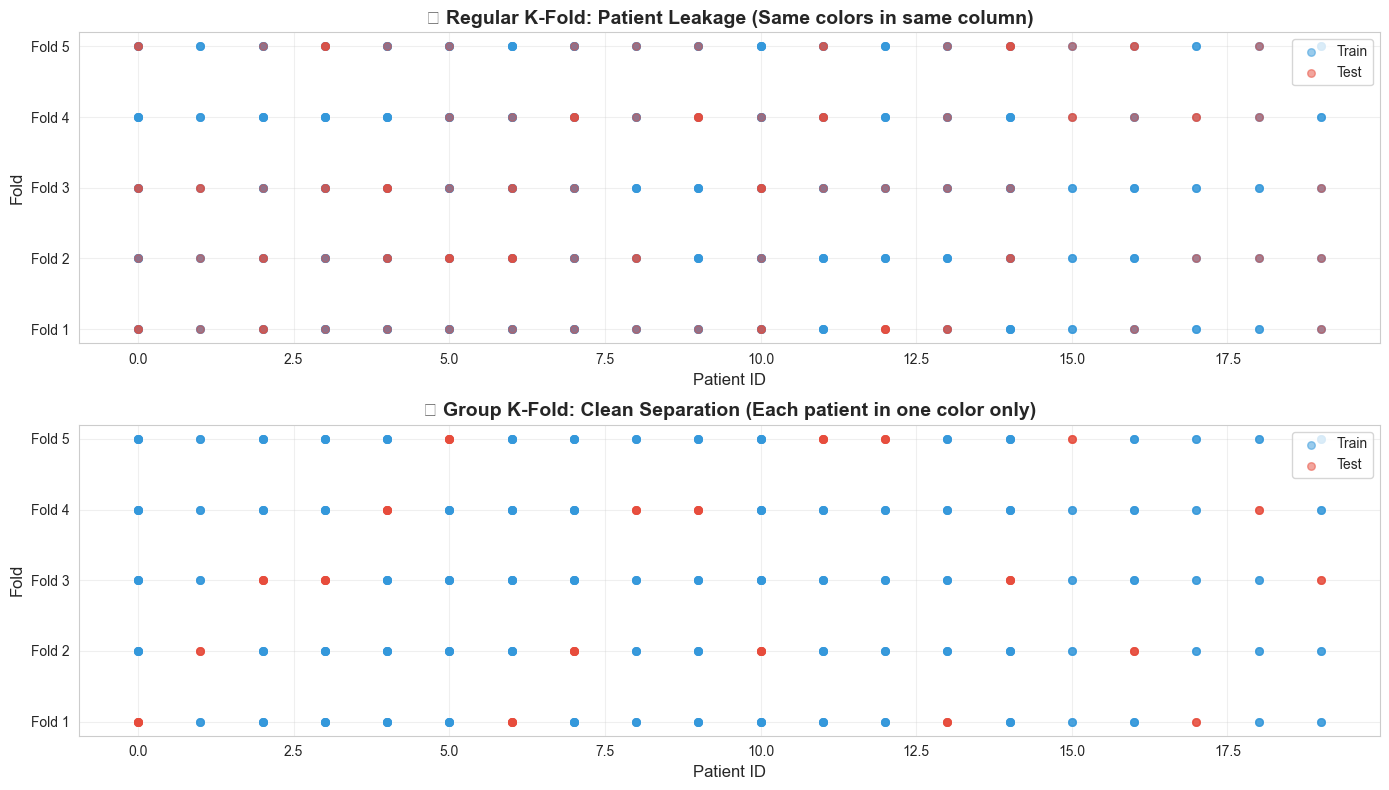


💡 Key Takeaway: For grouped data (patients, users, etc.), use GroupKFold!


array([0.86363636, 0.40909091, 0.36363636, 0.95238095, 0.33333333])

In [13]:
example_6_group_kfold()

## Hyperparameter Tuning Methods

### Grid Search
**Method**: Exhaustive search over predefined parameter grid

**Advantages**: Systematic, finds global optimum within grid

**Disadvantages**: Exponential complexity, curse of dimensionality

#### Example Grid
```python
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}
# Total combinations: 3 × 4 × 3 = 36
```

In [14]:
# ============================================================================
# EXAMPLE 7: GRID SEARCH HYPERPARAMETER TUNING
# ============================================================================

def example_7_grid_search():
    """
    Demonstrate Grid Search for hyperparameter tuning

    Key Learning: Systematic search through all combinations
    """
    print("\n" + "="*70)
    print("EXAMPLE 7: Grid Search Hyperparameter Tuning")
    print("="*70)

    # Load dataset
    wine = load_wine()
    X, y = wine.data, wine.target

    print(f"Dataset: Wine Classification")
    print(f"  Samples: {X.shape[0]}")
    print(f"  Features: {X.shape[1]}")
    print(f"  Classes: {len(np.unique(y))}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    print(f"\nTrain set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # Define parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10]
    }

    total_combinations = (len(param_grid['n_estimators']) *
                         len(param_grid['max_depth']) *
                         len(param_grid['min_samples_split']))

    print("\n" + "-"*70)
    print("Grid Search Configuration")
    print("-"*70)
    print(f"Parameters to tune:")
    for param, values in param_grid.items():
        print(f"  {param}: {values} ({len(values)} options)")
    print(f"\nTotal combinations: {total_combinations}")
    print(f"With 5-fold CV: {total_combinations * 5} model training runs!")

    # Perform Grid Search
    import time

    model = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy',
        n_jobs=-1,  # Use all CPU cores
        verbose=1,
        return_train_score=True
    )

    print("\n" + "-"*70)
    print("Starting Grid Search...")
    print("-"*70)

    start_time = time.time()
    grid_search.fit(X_train, y_train)
    search_time = time.time() - start_time

    print(f"\n✅ Grid Search completed in {search_time:.2f} seconds")

    # Best parameters
    print("\n" + "="*70)
    print("BEST MODEL FOUND")
    print("="*70)
    print("Best parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")

    print(f"\nBest CV Score: {grid_search.best_score_:.4f}")

    # Evaluate on test set
    test_score = grid_search.score(X_test, y_test)
    print(f"Test Set Score: {test_score:.4f}")

    # Analyze results
    results_df = pd.DataFrame(grid_search.cv_results_)

    # Show top 10 models
    print("\n" + "-"*70)
    print("Top 10 Models")
    print("-"*70)
    top_10 = results_df.nsmallest(10, 'rank_test_score')[
        ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    ]
    for idx, row in top_10.iterrows():
        print(f"Rank {int(row['rank_test_score'])}: "
              f"Score = {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")
        print(f"  Params: {row['params']}")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Effect of n_estimators
    for max_depth in param_grid['max_depth']:
        mask = results_df['param_max_depth'] == max_depth
        subset = results_df[mask]

        axes[0, 0].plot(subset['param_n_estimators'],
                       subset['mean_test_score'],
                       marker='o', label=f'max_depth={max_depth}')

    axes[0, 0].set_xlabel('n_estimators', fontsize=12)
    axes[0, 0].set_ylabel('CV Score', fontsize=12)
    axes[0, 0].set_title('Effect of n_estimators', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Plot 2: Heatmap of max_depth vs min_samples_split
    pivot_data = results_df.groupby(['param_max_depth', 'param_min_samples_split'])['mean_test_score'].mean().unstack()
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlGn',
               ax=axes[0, 1], cbar_kws={'label': 'CV Score'})
    axes[0, 1].set_title('max_depth vs min_samples_split',
                        fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('min_samples_split', fontsize=12)
    axes[0, 1].set_ylabel('max_depth', fontsize=12)

    # Plot 3: Score distribution
    axes[1, 0].hist(results_df['mean_test_score'], bins=20,
                   color='#3498db', alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(grid_search.best_score_, color='red',
                      linestyle='--', linewidth=2,
                      label=f'Best: {grid_search.best_score_:.3f}')
    axes[1, 0].set_xlabel('CV Score', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Distribution of CV Scores',
                        fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Plot 4: Train vs Test scores (check overfitting)
    axes[1, 1].scatter(results_df['mean_train_score'],
                      results_df['mean_test_score'],
                      alpha=0.6, s=50, c='#3498db', edgecolors='black')

    # Add diagonal line (perfect generalization)
    min_score = min(results_df['mean_train_score'].min(),
                   results_df['mean_test_score'].min())
    max_score = max(results_df['mean_train_score'].max(),
                   results_df['mean_test_score'].max())
    axes[1, 1].plot([min_score, max_score], [min_score, max_score],
                   'r--', linewidth=2, label='Perfect generalization')

    # Mark best model
    best_idx = grid_search.best_index_
    axes[1, 1].scatter(results_df.loc[best_idx, 'mean_train_score'],
                      results_df.loc[best_idx, 'mean_test_score'],
                      s=200, c='red', marker='*', edgecolors='black',
                      linewidth=2, label='Best model')

    axes[1, 1].set_xlabel('Train Score', fontsize=12)
    axes[1, 1].set_ylabel('Test Score', fontsize=12)
    axes[1, 1].set_title('Train vs Test Scores (Overfitting Check)',
                        fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('example_7_grid_search.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualization saved as 'example_7_grid_search.png'")
    plt.show()

    print("\n" + "="*70)
    print("Grid Search Summary")
    print("="*70)
    print(f"✅ Tried all {total_combinations} combinations systematically")
    print(f"✅ Found best parameters with CV score: {grid_search.best_score_:.4f}")
    print(f"✅ Test set performance: {test_score:.4f}")
    print(f"⏱️  Time taken: {search_time:.2f} seconds")
    print("="*70)

    return grid_search


EXAMPLE 7: Grid Search Hyperparameter Tuning
Dataset: Wine Classification
  Samples: 178
  Features: 13
  Classes: 3

Train set: 142 samples
Test set: 36 samples

----------------------------------------------------------------------
Grid Search Configuration
----------------------------------------------------------------------
Parameters to tune:
  n_estimators: [50, 100, 200] (3 options)
  max_depth: [3, 5, 7, None] (4 options)
  min_samples_split: [2, 5, 10] (3 options)

Total combinations: 36
With 5-fold CV: 180 model training runs!

----------------------------------------------------------------------
Starting Grid Search...
----------------------------------------------------------------------
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Grid Search completed in 5.29 seconds

BEST MODEL FOUND
Best parameters:
  max_depth: 3
  min_samples_split: 2
  n_estimators: 200

Best CV Score: 0.9791
Test Set Score: 1.0000

---------------------------------------------

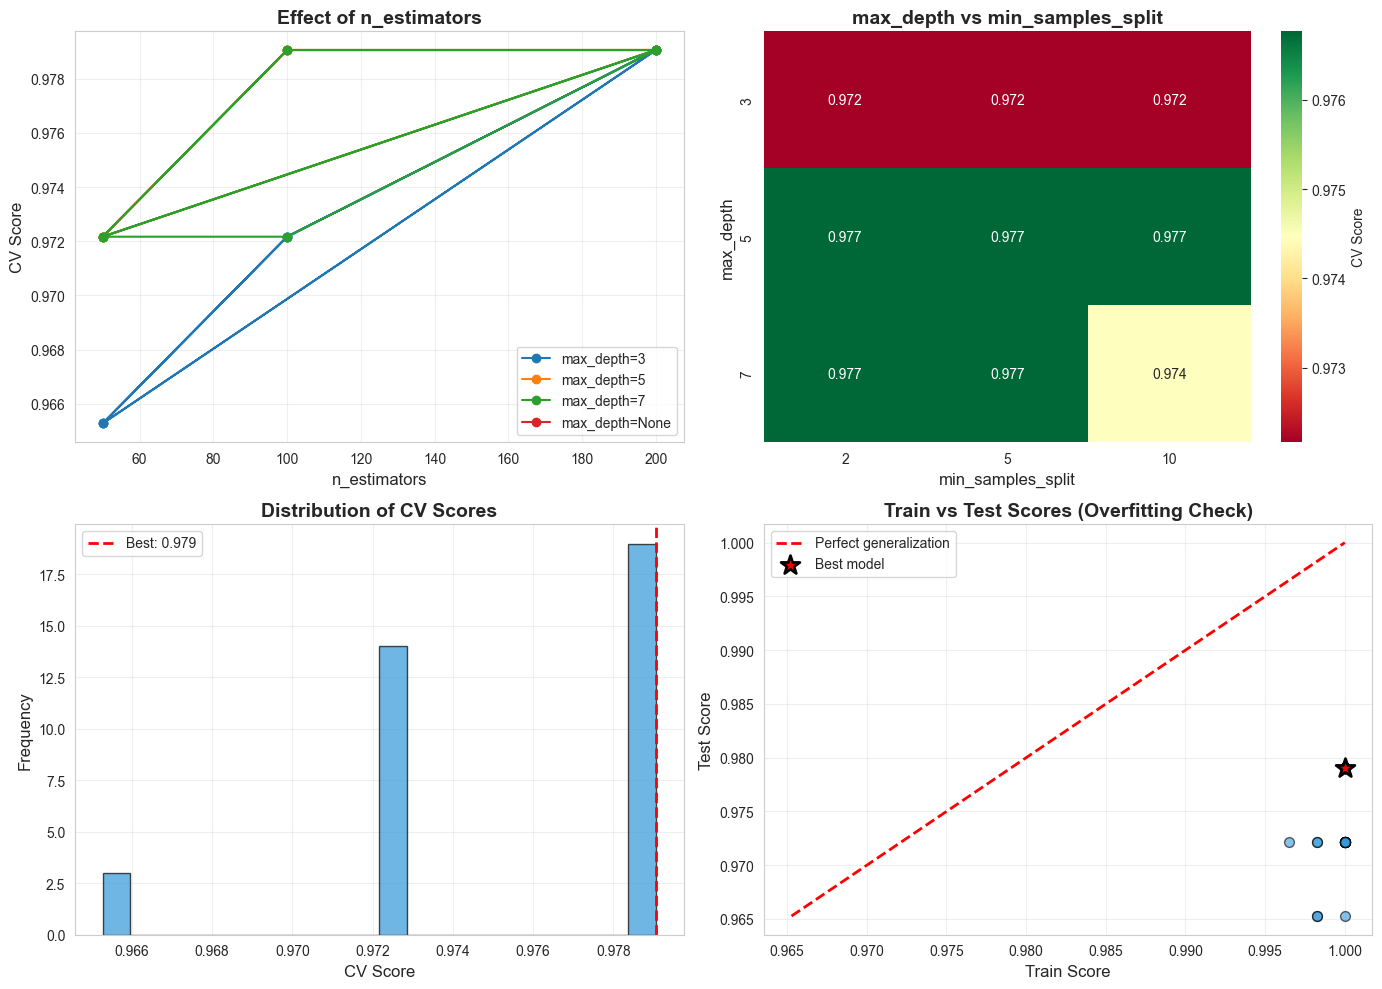


Grid Search Summary
✅ Tried all 36 combinations systematically
✅ Found best parameters with CV score: 0.9791
✅ Test set performance: 1.0000
⏱️  Time taken: 5.29 seconds


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,200


In [15]:
example_7_grid_search()

### Random Search

**Method**: Random sampling from parameter distributions

**Advantages**: More efficient for high dimensions, can find better solutions

**Theory**: Often 95% of performance achieved with <5% of evaluations


In [16]:
# ============================================================================
# EXAMPLE 8: RANDOM SEARCH HYPERPARAMETER TUNING
# ============================================================================

def example_8_random_search():
    """
    Demonstrate Random Search and compare with Grid Search

    Key Learning: More efficient for high-dimensional parameter spaces
    """
    print("\n" + "="*70)
    print("EXAMPLE 8: Random Search vs Grid Search")
    print("="*70)

    # Load dataset
    wine = load_wine()
    X, y = wine.data, wine.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    print(f"Dataset: Wine Classification")
    print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

    import time

    # Grid Search (smaller grid for comparison)
    print("\n" + "="*70)
    print("Method 1: Grid Search")
    print("="*70)

    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    grid_combinations = (len(param_grid['n_estimators']) *
                        len(param_grid['max_depth']) *
                        len(param_grid['min_samples_split']) *
                        len(param_grid['min_samples_leaf']))

    print(f"Total combinations: {grid_combinations}")

    model = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(
        model, param_grid, cv=5, n_jobs=-1, verbose=0
    )

    start_time = time.time()
    grid_search.fit(X_train, y_train)
    grid_time = time.time() - start_time

    print(f"Time: {grid_time:.2f} seconds")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    print(f"Best parameters: {grid_search.best_params_}")

    # Random Search
    print("\n" + "="*70)
    print("Method 2: Random Search")
    print("="*70)

    param_dist = {
        'n_estimators': randint(50, 200),
        'max_depth': [3, 5, 7, 10, 15, None],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]
    }

    n_iter = 50  # Try 50 random combinations

    print(f"Trying {n_iter} random combinations")
    print("(vs {grid_combinations} in Grid Search)")

    random_search = RandomizedSearchCV(
        model, param_dist, n_iter=n_iter, cv=5,
        n_jobs=-1, random_state=42, verbose=0
    )

    start_time = time.time()
    random_search.fit(X_train, y_train)
    random_time = time.time() - start_time

    print(f"Time: {random_time:.2f} seconds ({grid_time/random_time:.1f}x faster!)")
    print(f"Best CV Score: {random_search.best_score_:.4f}")
    print(f"Best parameters: {random_search.best_params_}")

    # Test set evaluation
    grid_test_score = grid_search.score(X_test, y_test)
    random_test_score = random_search.score(X_test, y_test)

    # Comparison
    print("\n" + "="*70)
    print("COMPARISON")
    print("="*70)

    comparison = pd.DataFrame({
        'Method': ['Grid Search', 'Random Search'],
        'Combinations Tried': [grid_combinations, n_iter],
        'Time (seconds)': [grid_time, random_time],
        'Best CV Score': [grid_search.best_score_, random_search.best_score_],
        'Test Score': [grid_test_score, random_test_score]
    })

    print(comparison.to_string(index=False))

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Time comparison
    methods = ['Grid Search', 'Random Search']
    times = [grid_time, random_time]
    colors = ['#3498db', '#2ecc71']

    axes[0, 0].bar(methods, times, color=colors, alpha=0.7,
                  edgecolor='black', linewidth=2)
    axes[0, 0].set_ylabel('Time (seconds)', fontsize=12)
    axes[0, 0].set_title('Computation Time', fontsize=14, fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)

    for i, time_val in enumerate(times):
        axes[0, 0].text(i, time_val + 0.5, f'{time_val:.1f}s',
                       ha='center', fontweight='bold')

    # Plot 2: Performance comparison
    cv_scores = [grid_search.best_score_, random_search.best_score_]
    test_scores = [grid_test_score, random_test_score]

    x = np.arange(2)
    width = 0.35

    axes[0, 1].bar(x - width/2, cv_scores, width, label='CV Score',
                  color='#3498db', alpha=0.7, edgecolor='black', linewidth=2)
    axes[0, 1].bar(x + width/2, test_scores, width, label='Test Score',
                  color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=2)
    axes[0, 1].set_ylabel('Score', fontsize=12)
    axes[0, 1].set_title('Performance Comparison', fontsize=14, fontweight='bold')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(methods)
    axes[0, 1].set_ylim([0.9, 1.0])
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)

    # Plot 3: Search progress (Random Search)
    random_results = pd.DataFrame(random_search.cv_results_)
    random_results = random_results.sort_values('mean_test_score', ascending=False)
    random_results['best_so_far'] = random_results['mean_test_score'].cummax()

    axes[1, 0].plot(range(1, n_iter + 1),
                   random_results.sort_index()['mean_test_score'].values,
                   'o', alpha=0.5, color='lightblue', label='Individual trial')
    axes[1, 0].plot(range(1, n_iter + 1),
                   random_results.sort_index()['best_so_far'].values,
                   linewidth=3, color='#e74c3c', label='Best so far')
    axes[1, 0].set_xlabel('Iteration', fontsize=12)
    axes[1, 0].set_ylabel('CV Score', fontsize=12)
    axes[1, 0].set_title('Random Search Progress', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Plot 4: Parameter importance visualization
    # Extract best n_estimators from both
    grid_n_est = grid_search.best_params_['n_estimators']
    random_n_est = random_search.best_params_['n_estimators']

    grid_depth = grid_search.best_params_['max_depth']
    random_depth = random_search.best_params_['max_depth']

    params = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']
    grid_vals = [
        grid_search.best_params_['n_estimators'],
        grid_search.best_params_['max_depth'] if grid_search.best_params_['max_depth'] else 20,
        grid_search.best_params_['min_samples_split'],
        grid_search.best_params_['min_samples_leaf']
    ]
    random_vals = [
        random_search.best_params_['n_estimators'],
        random_search.best_params_['max_depth'] if random_search.best_params_['max_depth'] else 20,
        random_search.best_params_['min_samples_split'],
        random_search.best_params_['min_samples_leaf']
    ]

    x_pos = np.arange(len(params))
    width = 0.35

    axes[1, 1].bar(x_pos - width/2, grid_vals, width,
                  label='Grid Search', color='#3498db', alpha=0.7,
                  edgecolor='black', linewidth=2)
    axes[1, 1].bar(x_pos + width/2, random_vals, width,
                  label='Random Search', color='#2ecc71', alpha=0.7,
                  edgecolor='black', linewidth=2)
    axes[1, 1].set_ylabel('Parameter Value', fontsize=12)
    axes[1, 1].set_title('Best Parameters Found', fontsize=14, fontweight='bold')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels(params, rotation=15, ha='right')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('example_8_random_search.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualization saved as 'example_8_random_search.png'")
    plt.show()

    print("\n" + "="*70)
    print("Key Takeaways:")
    print("="*70)
    print(f"✅ Random Search {grid_time/random_time:.1f}x faster")
    print(f"✅ Achieved similar performance ({random_test_score:.4f} vs {grid_test_score:.4f})")
    print("✅ Explored more parameter values (especially continuous ones)")
    print("✅ Default recommendation: Use Random Search with 50-100 iterations")
    print("="*70)

    return random_search



EXAMPLE 8: Random Search vs Grid Search
Dataset: Wine Classification
Train: 142, Test: 36

Method 1: Grid Search
Total combinations: 108
Time: 5.79 seconds
Best CV Score: 0.9862
Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Method 2: Random Search
Trying 50 random combinations
(vs {grid_combinations} in Grid Search)
Time: 3.07 seconds (1.9x faster!)
Best CV Score: 0.9862
Best parameters: {'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 16, 'n_estimators': 57}

COMPARISON
       Method  Combinations Tried  Time (seconds)  Best CV Score  Test Score
  Grid Search                 108        5.789367       0.986207    1.000000
Random Search                  50        3.072278       0.986207    0.972222

✅ Visualization saved as 'example_8_random_search.png'


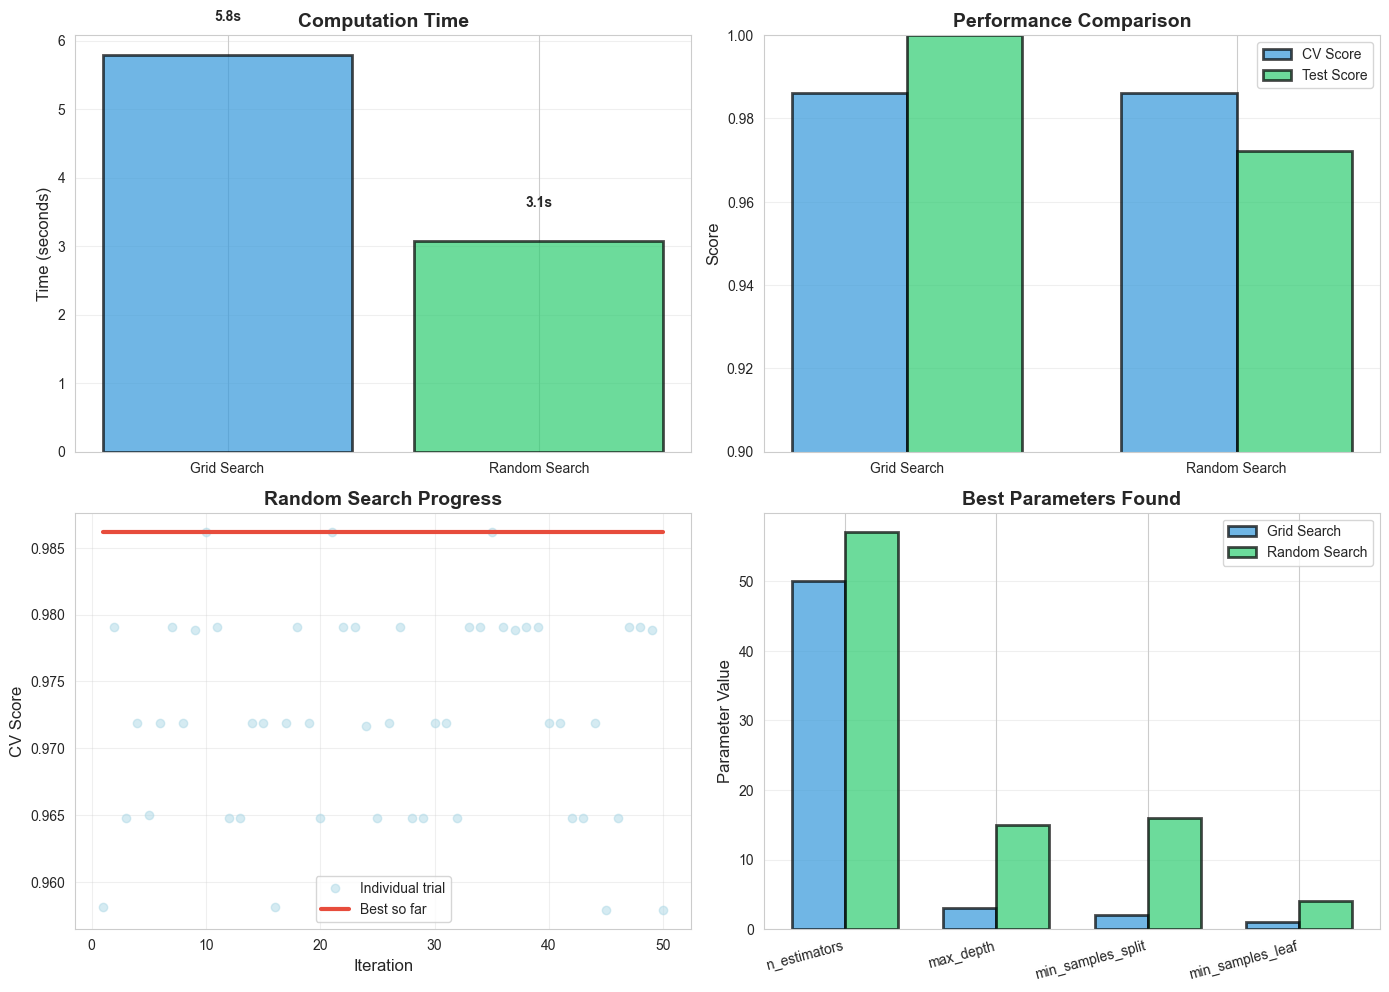


Key Takeaways:
✅ Random Search 1.9x faster
✅ Achieved similar performance (0.9722 vs 1.0000)
✅ Explored more parameter values (especially continuous ones)
✅ Default recommendation: Use Random Search with 50-100 iterations


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....t 0x12d991610>, 'min_samples_split': <scipy.stats....t 0x12d992f50>, ...}"
,n_iter,50
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [17]:
example_8_random_search()

#### Mathematical Insight
For grid search with n parameters, trying k values per parameter requires $k^n$ evaluations.
Random search tries random combinations, more likely to hit good values in high dimensions.

#### Popular Acquisition Functions
- **Expected Improvement (EI)**
- **Upper Confidence Bound (UCB)**
- **Probability of Improvement (PI)**

### Successive Halving
**Method**: Start with many configurations, progressively eliminate poor performers
**Advantage**: Efficient for expensive evaluations
**Implementation**: Hyperband, BOHB algorithms


In [18]:
# ============================================================================
# EXAMPLE 9: PIPELINE TO PREVENT DATA LEAKAGE
# ============================================================================

def example_9_pipeline_no_leakage():
    """
    Demonstrate how to use Pipeline to prevent data leakage

    Key Learning: ALWAYS preprocess inside CV, never before
    """
    print("\n" + "="*70)
    print("EXAMPLE 9: Pipeline to Prevent Data Leakage")
    print("="*70)

    # Generate dataset
    X, y = make_classification(
        n_samples=500, n_features=20, random_state=42
    )

    print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")

    # WRONG WAY: Scale before CV
    print("\n" + "="*70)
    print("❌ WRONG WAY: Preprocessing Before CV (Data Leakage)")
    print("="*70)

    scaler_wrong = StandardScaler()
    X_scaled_wrong = scaler_wrong.fit_transform(X)  # LEAKAGE!

    print("Step 1: Fit scaler on ALL data (including future test folds)")
    print(f"  Scaler learned: mean={scaler_wrong.mean_[:3]}, std={scaler_wrong.scale_[:3]}")
    print("  ⚠️  This includes statistics from test folds!")

    print("\nStep 2: Do cross-validation on scaled data")
    model = SVC(kernel='rbf', random_state=42)
    scores_wrong = cross_val_score(model, X_scaled_wrong, y, cv=5)

    print(f"CV Scores: {scores_wrong}")
    print(f"Mean: {scores_wrong.mean():.4f} ± {scores_wrong.std():.4f}")
    print("⚠️  This is OPTIMISTIC and WRONG!")
    print("   Test folds already influenced the scaler")

    # RIGHT WAY: Use Pipeline
    print("\n" + "="*70)
    print("✅ RIGHT WAY: Preprocessing in Pipeline (No Leakage)")
    print("="*70)

    pipeline_right = Pipeline([
        ('scaler', StandardScaler()),  # Fits INSIDE each CV fold
        ('classifier', SVC(kernel='rbf', random_state=42))
    ])

    print("Created Pipeline:")
    print("  Step 1: StandardScaler")
    print("  Step 2: SVC classifier")
    print("\nPipeline ensures scaler fits only on training folds")

    scores_right = cross_val_score(pipeline_right, X, y, cv=5)

    print(f"\nCV Scores: {scores_right}")
    print(f"Mean: {scores_right.mean():.4f} ± {scores_right.std():.4f}")
    print("✅ This is HONEST and CORRECT!")
    print("   Each fold's scaler only sees its own training data")

    # Detailed demonstration
    print("\n" + "-"*70)
    print("Detailed Process Comparison")
    print("-"*70)

    from sklearn.model_selection import KFold

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    print("\nWrong Way (Pre-scaling):")
    print("  Fold 1: Scaler already saw ALL data → Test on fold 1")
    print("  Fold 2: Scaler already saw ALL data → Test on fold 2")
    print("  ...")
    print("  ❌ Test folds influenced preprocessing!")

    print("\nRight Way (Pipeline):")
    fold_idx = 0
    for train_idx, test_idx in kfold.split(X):
        X_train_fold = X[train_idx]
        X_test_fold = X[test_idx]

        # What Pipeline does internally
        scaler_fold = StandardScaler()
        scaler_fold.fit(X_train_fold)  # Fit only on train

        if fold_idx == 0:
            print(f"  Fold {fold_idx + 1}:")
            print(f"    Scaler fits on train fold: {len(train_idx)} samples")
            print(f"    Scaler mean: {scaler_fold.mean_[:3]}")
            print(f"    Scaler std:  {scaler_fold.scale_[:3]}")
            print(f"    Then transforms both train and test using TRAIN statistics")
            print(f"    ✅ Test fold never influenced scaler!")

        fold_idx += 1

    # Quantify the leakage effect
    print("\n" + "="*70)
    print("Impact of Data Leakage")
    print("="*70)

    difference = scores_wrong.mean() - scores_right.mean()
    pct_inflation = (difference / scores_right.mean()) * 100

    print(f"Leaky score:   {scores_wrong.mean():.4f}")
    print(f"Honest score:  {scores_right.mean():.4f}")
    print(f"Difference:    {difference:.4f} ({pct_inflation:+.1f}% inflation)")

    if difference > 0:
        print("\n⚠️  Leaky approach overestimates performance!")
        print("   Your model will disappoint in production")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Fold-by-fold comparison
    x = np.arange(5)
    width = 0.35

    axes[0].bar(x - width/2, scores_wrong, width,
               label='❌ Leaky (Pre-scaling)', color='#e74c3c', alpha=0.7,
               edgecolor='black', linewidth=2)
    axes[0].bar(x + width/2, scores_right, width,
               label='✅ Correct (Pipeline)', color='#2ecc71', alpha=0.7,
               edgecolor='black', linewidth=2)

    axes[0].axhline(scores_wrong.mean(), color='#e74c3c', linestyle='--',
                   linewidth=2, alpha=0.7)
    axes[0].axhline(scores_right.mean(), color='#2ecc71', linestyle='--',
                   linewidth=2, alpha=0.7)

    axes[0].set_xlabel('Fold', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Data Leakage Effect on CV Scores',
                     fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'Fold {i+1}' for i in range(5)])
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Plot 2: Distribution comparison
    axes[1].violinplot([scores_wrong, scores_right],
                      positions=[0, 1], showmeans=True, showmedians=True)
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['❌ Leaky\n(Pre-scaling)', '✅ Correct\n(Pipeline)'])
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Score Distribution Comparison',
                     fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    # Add annotations
    axes[1].text(0, scores_wrong.mean() + 0.02,
                f'{scores_wrong.mean():.3f}',
                ha='center', fontweight='bold', color='#e74c3c')
    axes[1].text(1, scores_right.mean() + 0.02,
                f'{scores_right.mean():.3f}',
                ha='center', fontweight='bold', color='#2ecc71')

    plt.tight_layout()
    plt.savefig('example_9_pipeline_no_leakage.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualization saved as 'example_9_pipeline_no_leakage.png'")
    plt.show()

    # Code example
    print("\n" + "="*70)
    print("Code Template (Copy This!)")
    print("="*70)
    print("""
# ❌ WRONG - Don't do this:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Sees all data!
cross_val_score(model, X_scaled, y, cv=5)

# ✅ RIGHT - Always do this:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessing', StandardScaler()),
    ('model', RandomForestClassifier())
])

cross_val_score(pipeline, X, y, cv=5)  # Safe!
""")

    print("\n💡 Golden Rule: ALWAYS use Pipeline for any preprocessing!")
    print("="*70)

    return scores_right


EXAMPLE 9: Pipeline to Prevent Data Leakage
Dataset: 500 samples, 20 features

❌ WRONG WAY: Preprocessing Before CV (Data Leakage)
Step 1: Fit scaler on ALL data (including future test folds)
  Scaler learned: mean=[ 0.05349271 -0.06308705 -0.03292711], std=[1.04246108 0.97962858 0.99877449]
  ⚠️  This includes statistics from test folds!

Step 2: Do cross-validation on scaled data
CV Scores: [0.88 0.83 0.9  0.91 0.87]
Mean: 0.8780 ± 0.0279
⚠️  This is OPTIMISTIC and WRONG!
   Test folds already influenced the scaler

✅ RIGHT WAY: Preprocessing in Pipeline (No Leakage)
Created Pipeline:
  Step 1: StandardScaler
  Step 2: SVC classifier

Pipeline ensures scaler fits only on training folds

CV Scores: [0.88 0.83 0.91 0.9  0.87]
Mean: 0.8780 ± 0.0279
✅ This is HONEST and CORRECT!
   Each fold's scaler only sees its own training data

----------------------------------------------------------------------
Detailed Process Comparison
---------------------------------------------------------

/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/2500120403.py:162: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/2500120403.py:162: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/2500120403.py:163: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.savefig('example_9_pipeline_no_leakage.png', dpi=150, bbox_inches='tight')
/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/2500120403.py:163: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('example_9_pipeline_no_leakage.png', dpi=150, bbox_inches='tight')
/Users/xiaotingzhou/miniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Ari

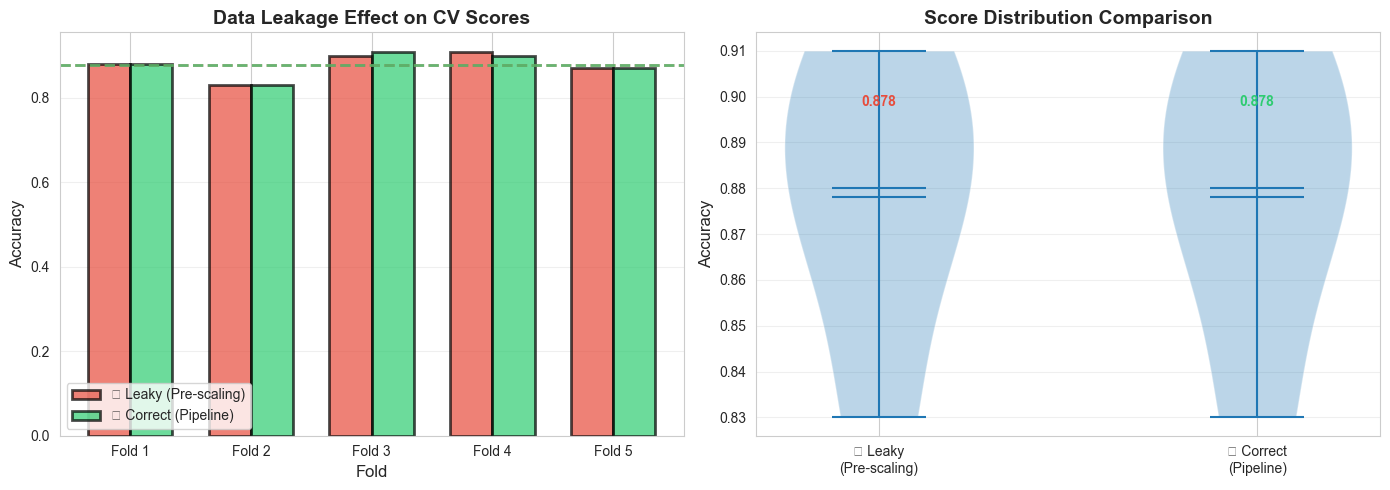


Code Template (Copy This!)

# ❌ WRONG - Don't do this:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Sees all data!
cross_val_score(model, X_scaled, y, cv=5)

# ✅ RIGHT - Always do this:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessing', StandardScaler()),
    ('model', RandomForestClassifier())
])

cross_val_score(pipeline, X, y, cv=5)  # Safe!


💡 Golden Rule: ALWAYS use Pipeline for any preprocessing!


array([0.88, 0.83, 0.91, 0.9 , 0.87])

In [19]:
example_9_pipeline_no_leakage()

## Advanced Validation Techniques

### Nested Cross-Validation
**Purpose**: Unbiased model selection and performance estimation
**Structure**:
- **Outer Loop**: Performance estimation
- **Inner Loop**: Hyperparameter tuning

```
For each outer fold:
    Use remaining data for inner CV to tune hyperparameters
    Train final model with best hyperparameters
    Evaluate on held-out outer fold
```

### Cross-Validation with Preprocessing
**Critical**: Apply preprocessing within each CV fold
**Wrong Way**: Preprocess entire dataset, then CV
**Right Way**: Preprocess within each fold separately

```python
# Correct approach
for train_idx, val_idx in cv_folds:
    X_train, X_val = X[train_idx], X[val_idx]
    
    # Fit preprocessing on training data only
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Train and evaluate model
```


## Hyperparameter Categories

### Model-Specific Parameters

#### Tree-Based Models
- **max_depth**: Maximum tree depth
- **min_samples_split**: Minimum samples to split node
- **min_samples_leaf**: Minimum samples in leaf
- **max_features**: Features considered per split

#### Neural Networks
- **learning_rate**: Step size for optimization
- **batch_size**: Samples per gradient update
- **hidden_units**: Neurons per layer
- **dropout_rate**: Regularization probability

#### SVM
- **C**: Regularization strength
- **gamma**: RBF kernel parameter
- **kernel**: Kernel type (linear, rbf, poly)


### Regularization Parameters
- **L1/L2 regularization**: α, λ parameters
- **Elastic Net**: Balance between L1 and L2
- **Dropout**: Neural network regularization

### Optimization Parameters
- **Solver**: Optimization algorithm
- **max_iterations**: Convergence limit
- **tolerance**: Convergence threshold

## Validation Strategies by Problem Type

### Small Datasets (n < 1000)
- **LOOCV** or high k (k=10+)
- **Stratified CV** for classification
- **Bootstrap validation** for very small datasets

### Large Datasets (n > 100,000)
- **Lower k** (k=3-5) for efficiency
- **Single holdout** validation set
- **Temporal splits** for time series

### Time Series
- **Walk-forward validation**
- **Expanding window**: Growing training set
- **Sliding window**: Fixed-size training set

### Imbalanced Data
- **Stratified CV** mandatory
- **Appropriate metrics**: F1, AUC-PR, not accuracy
- **Consider cost-sensitive evaluation**

## Early Stopping & Validation

### Early Stopping
**Method**: Stop training when validation performance stops improving
**Benefits**: Prevents overfitting, reduces training time
**Implementation**: Monitor validation loss with patience parameter

### Validation Curves
**Purpose**: Understand hyperparameter impact
**Method**: Plot performance vs parameter values
**Insight**: Identify underfitting/overfitting regions

### Learning Curves
**Purpose**: Diagnose model performance vs dataset size
**Insights**:
- **High bias**: Both curves plateau at low performance
- **High variance**: Large gap between training and validation

## Best Practices

### Computational Efficiency
- **Start simple**: Begin with default parameters
- **Coarse-to-fine**: Broad search first, then refine
- **Early stopping**: Use validation-based stopping
- **Parallel processing**: Leverage multiple cores

### Statistical Significance
- **Multiple seeds**: Run with different random seeds
- **Confidence intervals**: Report uncertainty in estimates
- **Statistical tests**: Compare models statistically

### Avoiding Overfitting
- **Separate test set**: Never use for hyperparameter tuning
- **Nested CV**: Unbiased performance estimation
- **Domain knowledge**: Use reasonable parameter ranges

In [32]:
# ============================================================================
# EXAMPLE 10: COMPLETE END-TO-END WORKFLOW
# ============================================================================

def example_10_complete_workflow():
    """
    Complete end-to-end ML workflow with proper cross-validation

    Key Learning: How to combine all best practices
    """
    print("\n" + "="*70)
    print("EXAMPLE 10: Complete End-to-End ML Workflow")
    print("="*70)

    # Load dataset
    print("\nStep 1: Load and Explore Data")
    print("-"*70)

    cancer = load_breast_cancer()
    X, y = cancer.data, cancer.target

    print(f"Dataset: Breast Cancer Detection")
    print(f"  Samples: {X.shape[0]}")
    print(f"  Features: {X.shape[1]}")
    print(f"  Classes: {cancer.target_names}")

    unique, counts = np.unique(y, return_counts=True)
    for cls, count, name in zip(unique, counts, cancer.target_names):
        print(f"    {name}: {count} ({count/len(y)*100:.1f}%)")

    # Step 2: Train-Test Split
    print("\nStep 2: Create Train-Test Split")
    print("-"*70)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples (HELD OUT)")
    print("✅ Test set will only be used for final evaluation!")

    # Step 3: Choose CV strategy
    print("\nStep 3: Choose Cross-Validation Strategy")
    print("-"*70)

    print("Data characteristics:")
    print("  - Classification task: Yes")
    print("  - Imbalanced classes: Slightly (63% vs 37%)")
    print("  - Time series: No")
    print("  - Grouped data: No")
    print("\n→ Decision: Use StratifiedKFold (maintains class ratio)")

    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Step 4: Create Pipeline
    print("\nStep 4: Create Pipeline (Avoid Data Leakage)")
    print("-"*70)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    print("Pipeline steps:")
    print("  1. StandardScaler (preprocessing)")
    print("  2. RandomForestClassifier (model)")
    print("✅ Scaler will fit separately in each CV fold")

    # Step 5: Hyperparameter tuning
    print("\nStep 5: Hyperparameter Tuning with Random Search")
    print("-"*70)

    param_dist = {
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [5, 10, 15, 20, None],
        'classifier__min_samples_split': randint(2, 20),
        'classifier__min_samples_leaf': randint(1, 10),
        'classifier__class_weight': ['balanced', None]
    }

    random_search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        n_iter=30,
        cv=cv_strategy,
        scoring='f1',  # F1 better for slightly imbalanced data
        n_jobs=-1,
        random_state=42,
        verbose=0,
        return_train_score=True  # ← 添加这一行！
    )

    print("Random Search configuration:")
    print(f"  Iterations: 30")
    print(f"  CV: StratifiedKFold (5 splits)")
    print(f"  Scoring: F1 (handles class imbalance)")
    print(f"  Total fits: 30 × 5 = 150")

    import time
    start_time = time.time()
    random_search.fit(X_train, y_train)
    search_time = time.time() - start_time

    print(f"\n✅ Hyperparameter search completed in {search_time:.2f}s")
    print(f"\nBest parameters:")
    for param, value in random_search.best_params_.items():
        print(f"  {param.split('__')[1]}: {value}")

    print(f"\nBest CV F1 Score: {random_search.best_score_:.4f}")

    # Step 6: Evaluate on test set
    print("\nStep 6: Final Evaluation on Test Set")
    print("-"*70)
    print("⚠️  NOW and ONLY NOW we touch the test set!")

    y_pred = random_search.predict(X_test)
    y_pred_proba = random_search.predict_proba(X_test)[:, 1]

    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        roc_auc_score, confusion_matrix, classification_report
    )

    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)

    print("\nTest Set Results:")
    print(f"  Accuracy:  {test_accuracy:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall:    {test_recall:.4f}")
    print(f"  F1 Score:  {test_f1:.4f}")
    print(f"  ROC-AUC:   {test_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=cancer.target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Visualization
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # Plot 1: Confusion Matrix
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=cancer.target_names,
                yticklabels=cancer.target_names,
                cbar_kws={'label': 'Count'})
    ax1.set_ylabel('True Label', fontsize=11)
    ax1.set_xlabel('Predicted Label', fontsize=11)
    ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

    # Plot 2: ROC Curve
    from sklearn.metrics import roc_curve

    ax2 = fig.add_subplot(gs[0, 1])
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    ax2.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {test_auc:.3f})',
            color='#3498db')
    ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=11)
    ax2.set_ylabel('True Positive Rate', fontsize=11)
    ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)

    # Plot 3: Metrics Comparison
    ax3 = fig.add_subplot(gs[0, 2])
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
    values = [test_accuracy, test_precision, test_recall, test_f1, test_auc]
    colors_metrics = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

    bars = ax3.bar(metrics, values, color=colors_metrics, alpha=0.7,
                   edgecolor='black', linewidth=2)
    ax3.set_ylabel('Score', fontsize=11)
    ax3.set_title('Test Set Metrics', fontsize=12, fontweight='bold')
    ax3.set_ylim([0, 1.1])
    ax3.grid(axis='y', alpha=0.3)

    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Plot 4: CV Score Distribution
    ax4 = fig.add_subplot(gs[1, 0])
    cv_results = pd.DataFrame(random_search.cv_results_)
    ax4.hist(cv_results['mean_test_score'], bins=20, color='#3498db',
            alpha=0.7, edgecolor='black')
    ax4.axvline(random_search.best_score_, color='red', linestyle='--',
               linewidth=2, label=f'Best: {random_search.best_score_:.3f}')
    ax4.set_xlabel('CV F1 Score', fontsize=11)
    ax4.set_ylabel('Frequency', fontsize=11)
    ax4.set_title('Cross-Validation Score Distribution',
                 fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(alpha=0.3)

    # Plot 5: Search Progress
    ax5 = fig.add_subplot(gs[1, 1])
    cv_results_sorted = cv_results.sort_index()
    cv_results_sorted['best_so_far'] = cv_results_sorted['mean_test_score'].cummax()

    ax5.plot(range(1, 31), cv_results_sorted['mean_test_score'].values,
            'o', alpha=0.4, color='lightblue', label='Trial')
    ax5.plot(range(1, 31), cv_results_sorted['best_so_far'].values,
            linewidth=3, color='#e74c3c', label='Best so far')
    ax5.set_xlabel('Iteration', fontsize=11)
    ax5.set_ylabel('CV F1 Score', fontsize=11)
    ax5.set_title('Hyperparameter Search Progress',
                 fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(alpha=0.3)

    # Plot 6: Feature Importance (top 10)
    ax6 = fig.add_subplot(gs[1, 2])

    # Get feature importances from best model
    best_model = random_search.best_estimator_.named_steps['classifier']
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]

    feature_names = [cancer.feature_names[i] for i in indices]
    importance_values = importances[indices]

    ax6.barh(range(10), importance_values, color='#2ecc71', alpha=0.7,
            edgecolor='black', linewidth=1.5)
    ax6.set_yticks(range(10))
    ax6.set_yticklabels(feature_names, fontsize=9)
    ax6.set_xlabel('Importance', fontsize=11)
    ax6.set_title('Top 10 Feature Importances', fontsize=12, fontweight='bold')
    ax6.invert_yaxis()
    ax6.grid(axis='x', alpha=0.3)

    # Plot 7: Train vs CV scores (overfitting check)
    ax7 = fig.add_subplot(gs[2, :2])

    ax7.scatter(cv_results['mean_train_score'], cv_results['mean_test_score'],
               alpha=0.5, s=50, c='#3498db', edgecolors='black')

    # Diagonal line
    min_score = min(cv_results['mean_train_score'].min(),
                   cv_results['mean_test_score'].min())
    max_score = max(cv_results['mean_train_score'].max(),
                   cv_results['mean_test_score'].max())
    ax7.plot([min_score, max_score], [min_score, max_score], 'r--',
            linewidth=2, label='Perfect generalization')

    # Best model
    best_idx = random_search.best_index_
    ax7.scatter(cv_results.loc[best_idx, 'mean_train_score'],
               cv_results.loc[best_idx, 'mean_test_score'],
               s=200, c='red', marker='*', edgecolors='black',
               linewidth=2, label='Best model', zorder=5)

    ax7.set_xlabel('Train F1 Score', fontsize=11)
    ax7.set_ylabel('CV F1 Score', fontsize=11)
    ax7.set_title('Overfitting Check: Train vs CV Scores',
                 fontsize=12, fontweight='bold')
    ax7.legend()
    ax7.grid(alpha=0.3)

    # Plot 8: Summary text
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.axis('off')

    summary_text = f"""
    WORKFLOW SUMMARY
    {'='*30}

    ✅ Dataset Split:
       Train: {X_train.shape[0]} samples
       Test: {X_test.shape[0]} samples

    ✅ CV Strategy:
       StratifiedKFold (k=5)

    ✅ Pipeline:
       StandardScaler + RF

    ✅ Hyperparameter Tuning:
       Random Search (30 iter)
       Time: {search_time:.1f}s

    ✅ Best CV Score:
       F1: {random_search.best_score_:.4f}

    ✅ Test Performance:
       Accuracy: {test_accuracy:.4f}
       F1 Score: {test_f1:.4f}
       ROC-AUC:  {test_auc:.4f}

    {'='*30}
    ✓ No data leakage
    ✓ Proper validation
    ✓ Ready for deployment
    """

    ax8.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
            verticalalignment='center', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.3))

    plt.suptitle('Complete ML Workflow: Breast Cancer Detection',
                fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('example_10_complete_workflow.png', dpi=150, bbox_inches='tight')
    print("\n✅ Complete visualization saved as 'example_10_complete_workflow.png'")
      # 在 plt.show() 之前添加
    plt.tight_layout(pad=2.0)  # 自动调整布局，pad控制边距

    # 或者手动微调
    plt.subplots_adjust(
        left=0.05,    # 左边距
        right=0.95,   # 右边距
        top=0.95,     # 上边距
        bottom=0.05,  # 下边距
        hspace=0.5,   # 垂直间距
        wspace=0.4    # 水平间距
    )

    plt.show()

    # Final recommendations
    print("\n" + "="*70)
    print("WORKFLOW CHECKLIST - Did we do everything right?")
    print("="*70)
    print("✅ 1. Split data into train/test at the beginning")
    print("✅ 2. Chose appropriate CV strategy (StratifiedKFold)")
    print("✅ 3. Used Pipeline to prevent data leakage")
    print("✅ 4. Tuned hyperparameters on training set only")
    print("✅ 5. Touched test set only once at the end")
    print("✅ 6. Used appropriate metrics (F1 for imbalanced data)")
    print("✅ 7. Checked for overfitting (train vs CV scores)")
    print("✅ 8. Documented and visualized results")
    print("="*70)
    print("\n🎉 Congratulations! You followed all best practices!")
    print("   This model is ready for production deployment.")
    print("="*70)

    return random_search


EXAMPLE 10: Complete End-to-End ML Workflow

Step 1: Load and Explore Data
----------------------------------------------------------------------
Dataset: Breast Cancer Detection
  Samples: 569
  Features: 30
  Classes: ['malignant' 'benign']
    malignant: 212 (37.3%)
    benign: 357 (62.7%)

Step 2: Create Train-Test Split
----------------------------------------------------------------------
Train set: 455 samples
Test set: 114 samples (HELD OUT)
✅ Test set will only be used for final evaluation!

Step 3: Choose Cross-Validation Strategy
----------------------------------------------------------------------
Data characteristics:
  - Classification task: Yes
  - Imbalanced classes: Slightly (63% vs 37%)
  - Time series: No
  - Grouped data: No

→ Decision: Use StratifiedKFold (maintains class ratio)

Step 4: Create Pipeline (Avoid Data Leakage)
----------------------------------------------------------------------
Pipeline steps:
  1. StandardScaler (preprocessing)
  2. RandomForest

/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/1003932578.py:313: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('example_10_complete_workflow.png', dpi=150, bbox_inches='tight')



✅ Complete visualization saved as 'example_10_complete_workflow.png'


/var/folders/48/zcq5ydb90d53q6sd6g4zy7f00000gn/T/ipykernel_85789/1003932578.py:316: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)  # 自动调整布局，pad控制边距
/Users/xiaotingzhou/miniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


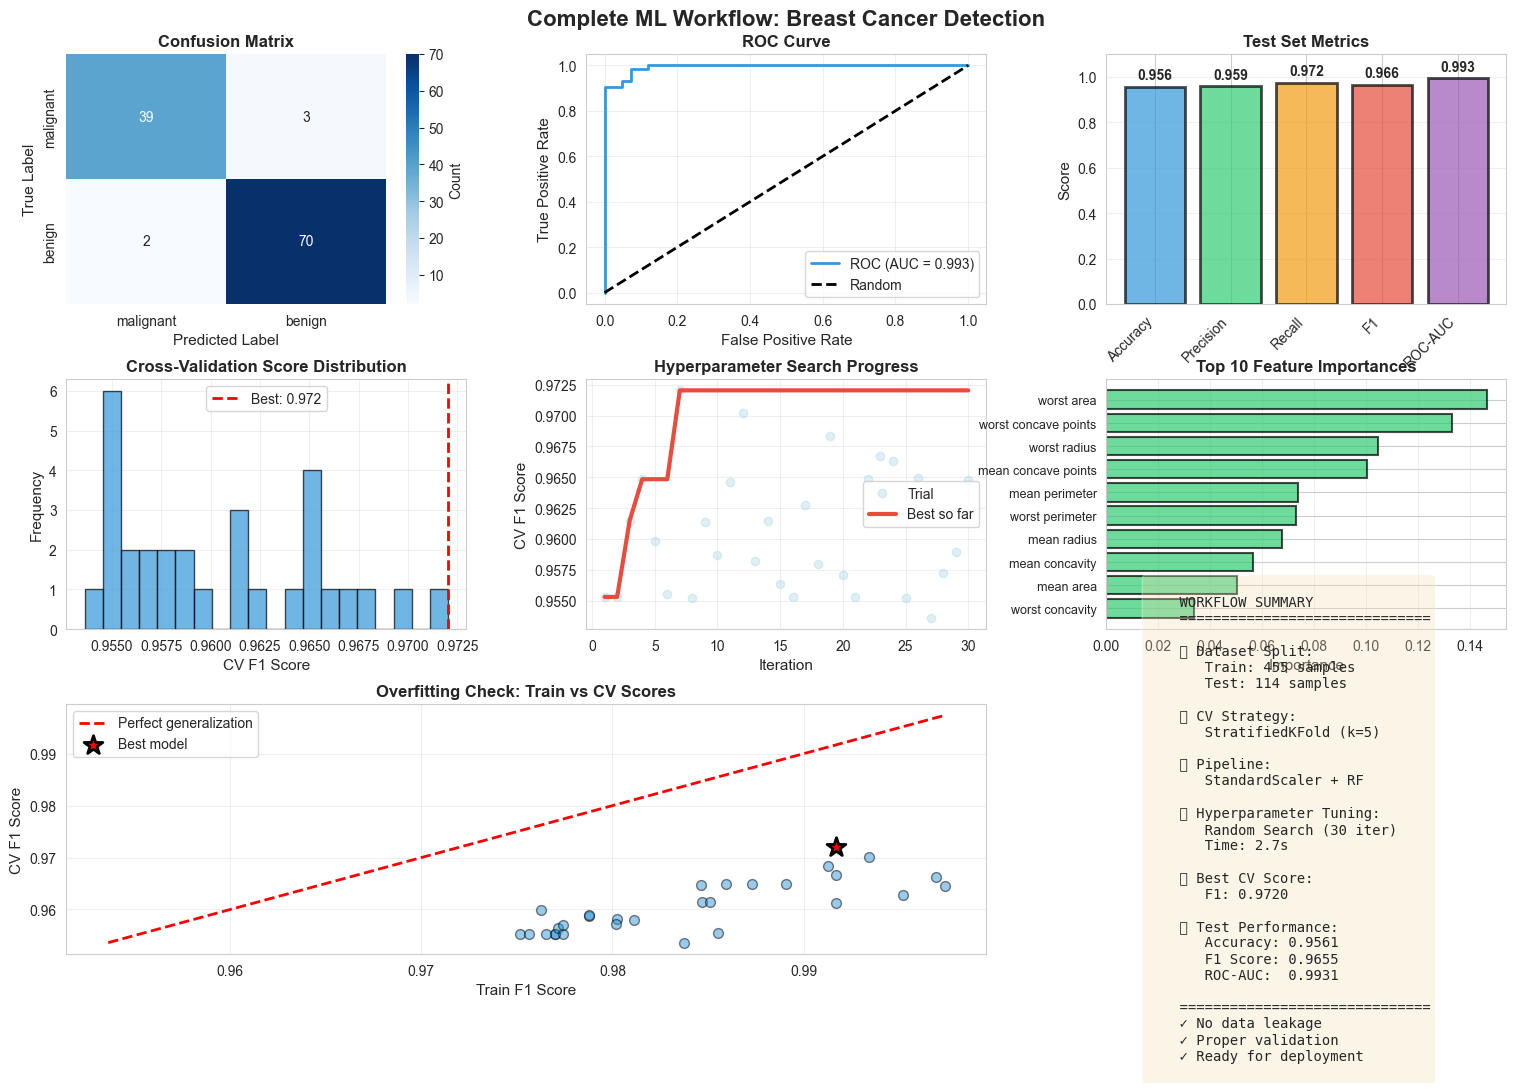


WORKFLOW CHECKLIST - Did we do everything right?
✅ 1. Split data into train/test at the beginning
✅ 2. Chose appropriate CV strategy (StratifiedKFold)
✅ 3. Used Pipeline to prevent data leakage
✅ 4. Tuned hyperparameters on training set only
✅ 5. Touched test set only once at the end
✅ 6. Used appropriate metrics (F1 for imbalanced data)
✅ 7. Checked for overfitting (train vs CV scores)
✅ 8. Documented and visualized results

🎉 Congratulations! You followed all best practices!
   This model is ready for production deployment.


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__class_weight': ['balanced', None], 'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_leaf': <scipy.stats....t 0x13b803cd0>, 'classifier__min_samples_split': <scipy.stats....t 0x13b9dee50>, ...}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [33]:
example_10_complete_workflow()

In [26]:
# Cross-Validation & Hyperparameter Tuning Comprehensive Demo

# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, KFold, LeaveOneOut,
    GridSearchCV, RandomizedSearchCV, validation_curve,
    TimeSeriesSplit, GroupKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
import time

print("=== CROSS-VALIDATION & HYPERPARAMETER TUNING DEMO ===")


=== CROSS-VALIDATION & HYPERPARAMETER TUNING DEMO ===


In [27]:
# Generate dataset for demonstrations
X_cv, y_cv = make_classification(
    n_samples=1000, n_features=20, n_informative=15, n_redundant=5,
    n_classes=3, random_state=42
)

print(f"Dataset shape: {X_cv.shape}")
print(f"Classes distribution: {np.bincount(y_cv)}")


Dataset shape: (1000, 20)
Classes distribution: [333 331 336]


In [28]:
# Demo 1: Different Cross-Validation Strategies
print("\n=== CROSS-VALIDATION STRATEGIES COMPARISON ===")

# Create models for comparison
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'SVM': SVC(random_state=42)
}



=== CROSS-VALIDATION STRATEGIES COMPARISON ===


In [29]:
# Different CV strategies
cv_strategies = {
    'K-Fold (k=5)': KFold(n_splits=5, shuffle=True, random_state=42),
    'Stratified K-Fold (k=5)': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'K-Fold (k=10)': KFold(n_splits=10, shuffle=True, random_state=42),
    'Leave-One-Out': LeaveOneOut() if len(X_cv) <= 200 else StratifiedKFold(n_splits=min(len(X_cv)//10, 20), shuffle=True, random_state=42)
}

# Note: Using subset for LOOCV due to computational constraints
if len(X_cv) > 200:
    print("Note: Using subset for LOOCV demonstration due to computational constraints")
    X_loocv, y_loocv = X_cv[:200], y_cv[:200]
    cv_strategies['Leave-One-Out'] = LeaveOneOut()
else:
    X_loocv, y_loocv = X_cv, y_cv


Note: Using subset for LOOCV demonstration due to computational constraints


In [30]:
cv_results = {}

for model_name, model in models.items():
    cv_results[model_name] = {}
    print(f"\n{model_name} Results:")

    for cv_name, cv_strategy in cv_strategies.items():
        if cv_name == 'Leave-One-Out':
            # Use smaller dataset for LOOCV
            scores = cross_val_score(model, X_loocv, y_loocv, cv=cv_strategy, scoring='accuracy')
        else:
            scores = cross_val_score(model, X_cv, y_cv, cv=cv_strategy, scoring='accuracy')

        cv_results[model_name][cv_name] = {
            'mean': scores.mean(),
            'std': scores.std(),
            'scores': scores
        }

        print(f"  {cv_name:>20}: {scores.mean():.3f} ± {scores.std():.3f}")



Logistic Regression Results:
          K-Fold (k=5): 0.687 ± 0.022
  Stratified K-Fold (k=5): 0.676 ± 0.008
         K-Fold (k=10): 0.684 ± 0.050
         Leave-One-Out: 0.595 ± 0.491

Random Forest Results:
          K-Fold (k=5): 0.781 ± 0.025
  Stratified K-Fold (k=5): 0.783 ± 0.031
         K-Fold (k=10): 0.786 ± 0.029
         Leave-One-Out: 0.660 ± 0.474

SVM Results:
          K-Fold (k=5): 0.831 ± 0.025
  Stratified K-Fold (k=5): 0.835 ± 0.009
         K-Fold (k=10): 0.845 ± 0.040
         Leave-One-Out: 0.785 ± 0.411


In [31]:
# Demo 2: Grid Search Hyperparameter Tuning
print("\n=== GRID SEARCH HYPERPARAMETER TUNING ===")

# Define parameter grids
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']  # Supports both l1 and l2
    }
}


=== GRID SEARCH HYPERPARAMETER TUNING ===


In [32]:
grid_search_results = {}

for model_name in ['Random Forest', 'SVM']:  # Skip LogReg for time
    print(f"\nGrid Search for {model_name}:")

    if model_name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=42)
        param_grid = param_grids[model_name]
        # Reduce grid size for demo
        param_grid = {
            'n_estimators': [50, 100],
            'max_depth': [3, 5, None],
            'min_samples_split': [2, 5]
        }
    else:  # SVM
        base_model = SVC(random_state=42)
        param_grid = param_grids[model_name]
        # Reduce grid size for demo
        param_grid = {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 0.01, 0.1],
            'kernel': ['rbf', 'linear']
        }

    start_time = time.time()
    grid_search = GridSearchCV(
        base_model, param_grid, cv=5, scoring='accuracy',
        n_jobs=-1, return_train_score=True
    )
    grid_search.fit(X_cv, y_cv)
    end_time = time.time()

    grid_search_results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'time_taken': end_time - start_time,
        'n_combinations': len(grid_search.cv_results_['mean_test_score'])
    }

    print(f"  Best parameters: {grid_search.best_params_}")
    print(f"  Best CV score: {grid_search.best_score_:.3f}")
    print(f"  Total combinations tested: {len(grid_search.cv_results_['mean_test_score'])}")
    print(f"  Time taken: {end_time - start_time:.2f} seconds")



Grid Search for Random Forest:
  Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV score: 0.784
  Total combinations tested: 12
  Time taken: 3.43 seconds

Grid Search for SVM:
  Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV score: 0.871
  Total combinations tested: 18
  Time taken: 5.57 seconds


In [33]:
# Demo 3: Random Search vs Grid Search Comparison
print("\n=== RANDOM SEARCH VS GRID SEARCH COMPARISON ===")

# Focus on Random Forest for detailed comparison
rf_param_dist = {
    'n_estimators': randint(10, 200),
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

# Grid search (smaller grid)
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 7, None],
    'min_samples_split': [2, 5, 10]
}

# Random search
print("Random Search:")
start_time = time.time()
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), rf_param_dist,
    n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42
)
random_search.fit(X_cv, y_cv)
random_time = time.time() - start_time

print(f"  Best parameters: {random_search.best_params_}")
print(f"  Best CV score: {random_search.best_score_:.3f}")
print(f"  Time taken: {random_time:.2f} seconds")
print(f"  Combinations tested: 20")

# Grid search
print("\nGrid Search (reduced grid):")
start_time = time.time()
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42), rf_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_search_rf.fit(X_cv, y_cv)
grid_time = time.time() - start_time

print(f"  Best parameters: {grid_search_rf.best_params_}")
print(f"  Best CV score: {grid_search_rf.best_score_:.3f}")
print(f"  Time taken: {grid_time:.2f} seconds")
print(f"  Combinations tested: {len(grid_search_rf.cv_results_['mean_test_score'])}")


=== RANDOM SEARCH VS GRID SEARCH COMPARISON ===
Random Search:
  Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 60}
  Best CV score: 0.772
  Time taken: 2.85 seconds
  Combinations tested: 20

Grid Search (reduced grid):
  Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
  Best CV score: 0.787
  Time taken: 3.47 seconds
  Combinations tested: 27


In [35]:
# Demo 4: Nested Cross-Validation
print("\n=== NESTED CROSS-VALIDATION DEMO ===")

def nested_cv_score(model, param_grid, X, y, outer_cv=5, inner_cv=3):
    """
    Perform nested cross-validation for unbiased model evaluation
    """
    outer_scores = []
    outer_cv_splitter = StratifiedKFold(n_splits=outer_cv, shuffle=True, random_state=42)

    for train_idx, test_idx in outer_cv_splitter.split(X, y):
        X_train_outer, X_test_outer = X[train_idx], X[test_idx]
        y_train_outer, y_test_outer = y[train_idx], y[test_idx]

        # Inner CV for hyperparameter tuning
        inner_cv_splitter = StratifiedKFold(n_splits=inner_cv, shuffle=True, random_state=42)
        grid_search = GridSearchCV(
            model, param_grid, cv=inner_cv_splitter,
            scoring='accuracy', n_jobs=-1
        )
        grid_search.fit(X_train_outer, y_train_outer)

        # Evaluate best model on outer test set
        best_model = grid_search.best_estimator_
        outer_score = best_model.score(X_test_outer, y_test_outer)
        outer_scores.append(outer_score)

    return np.array(outer_scores)

# Perform nested CV on Random Forest
nested_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None]
}

print("Performing Nested Cross-Validation (may take a moment)...")
nested_scores = nested_cv_score(
    RandomForestClassifier(random_state=42),
    nested_param_grid, X_cv, y_cv
)
print(f"Nested CV Scores: {nested_scores}")
print(f"Mean nested CV score: {nested_scores.mean():.3f} ± {nested_scores.std():.3f}")
print(f"This represents unbiased estimate of model performance")



=== NESTED CROSS-VALIDATION DEMO ===
Performing Nested Cross-Validation (may take a moment)...
Nested CV Scores: [0.785 0.83  0.79  0.76  0.795]
Mean nested CV score: 0.792 ± 0.022
This represents unbiased estimate of model performance


In [36]:
# Demo 5: Validation Curves
print("\n=== VALIDATION CURVES ANALYSIS ===")

# Validation curve for Random Forest n_estimators
param_range = [10, 25, 50, 100, 150, 200]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42), X_cv, y_cv,
    param_name='n_estimators', param_range=param_range,
    cv=5, scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

print("Validation Curve Results (n_estimators):")
for i, n_est in enumerate(param_range):
    print(f"  n_estimators={n_est:3d}: Train={train_mean[i]:.3f}±{train_std[i]:.3f}, "
          f"Val={val_mean[i]:.3f}±{val_std[i]:.3f}")



=== VALIDATION CURVES ANALYSIS ===
Validation Curve Results (n_estimators):
  n_estimators= 10: Train=0.990±0.004, Val=0.695±0.025
  n_estimators= 25: Train=1.000±0.000, Val=0.755±0.033
  n_estimators= 50: Train=1.000±0.000, Val=0.767±0.043
  n_estimators=100: Train=1.000±0.000, Val=0.784±0.032
  n_estimators=150: Train=1.000±0.000, Val=0.787±0.034
  n_estimators=200: Train=1.000±0.000, Val=0.789±0.033


In [37]:
# Demo 6: Time Series Cross-Validation
print("\n=== TIME SERIES CROSS-VALIDATION DEMO ===")

# Generate time series-like data
np.random.seed(42)
n_samples = 200
X_ts = np.random.randn(n_samples, 5)
# Add time dependency
for i in range(1, n_samples):
    X_ts[i, 0] += 0.5 * X_ts[i-1, 0]  # AR(1) process
y_ts = (X_ts[:, 0] + X_ts[:, 1] + np.random.randn(n_samples) * 0.1 > 0).astype(int)

print(f"Time series dataset shape: {X_ts.shape}")

# Compare regular CV vs Time Series CV
regular_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ts_cv = TimeSeriesSplit(n_splits=5)

model_ts = RandomForestClassifier(n_estimators=50, random_state=42)

# Regular CV (wrong for time series!)
regular_scores = cross_val_score(model_ts, X_ts, y_ts, cv=regular_cv)
print(f"Regular K-Fold CV (inappropriate): {regular_scores.mean():.3f} ± {regular_scores.std():.3f}")

# Time Series CV (correct approach)
ts_scores = cross_val_score(model_ts, X_ts, y_ts, cv=ts_cv)
print(f"Time Series CV (appropriate): {ts_scores.mean():.3f} ± {ts_scores.std():.3f}")

print("Note: Time Series CV typically gives more conservative estimates")



=== TIME SERIES CROSS-VALIDATION DEMO ===
Time series dataset shape: (200, 5)
Regular K-Fold CV (inappropriate): 0.935 ± 0.051
Time Series CV (appropriate): 0.915 ± 0.030
Note: Time Series CV typically gives more conservative estimates


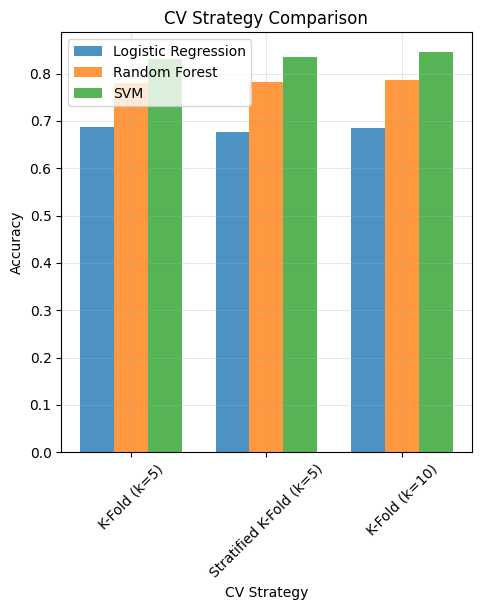

In [38]:
import matplotlib.pyplot as plt
# Visualization
plt.figure(figsize=(18, 12))

# Plot 1: CV Strategy Comparison
plt.subplot(2, 3, 1)
cv_methods = list(cv_strategies.keys())[:3]  # First 3 methods
lr_scores = [cv_results['Logistic Regression'][method]['mean'] for method in cv_methods]
rf_scores = [cv_results['Random Forest'][method]['mean'] for method in cv_methods]
svm_scores = [cv_results['SVM'][method]['mean'] for method in cv_methods]

x = np.arange(len(cv_methods))
width = 0.25

plt.bar(x - width, lr_scores, width, label='Logistic Regression', alpha=0.8)
plt.bar(x, rf_scores, width, label='Random Forest', alpha=0.8)
plt.bar(x + width, svm_scores, width, label='SVM', alpha=0.8)

plt.xlabel('CV Strategy')
plt.ylabel('Accuracy')
plt.title('CV Strategy Comparison')
plt.xticks(x, cv_methods, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

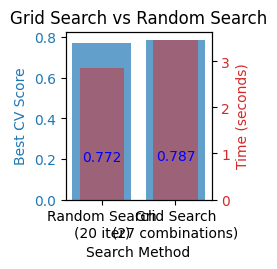

In [39]:
# Plot 2: Grid Search vs Random Search
plt.subplot(2, 3, 2)
methods = ['Random Search\n(20 iter)', 'Grid Search\n(27 combinations)']
scores = [random_search.best_score_, grid_search_rf.best_score_]
times = [random_time, grid_time]

fig_ax = plt.gca()
color = 'tab:blue'
fig_ax.set_xlabel('Search Method')
fig_ax.set_ylabel('Best CV Score', color=color)
bars1 = fig_ax.bar(methods, scores, color=color, alpha=0.7)
fig_ax.tick_params(axis='y', labelcolor=color)

# Add time on secondary y-axis
ax2 = fig_ax.twinx()
color = 'tab:red'
ax2.set_ylabel('Time (seconds)', color=color)
bars2 = ax2.bar(methods, times, color=color, alpha=0.5, width=0.6)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Grid Search vs Random Search')

# Add value labels
for bar, score in zip(bars1, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', color='blue')


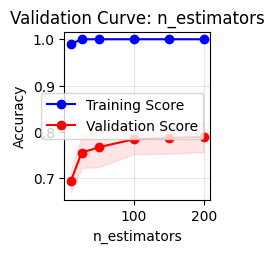

In [40]:
# Plot 3: Validation Curve
plt.subplot(2, 3, 3)
plt.plot(param_range, train_mean, 'o-', label='Training Score', color='blue')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(param_range, val_mean, 'o-', label='Validation Score', color='red')
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')

plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Validation Curve: n_estimators')
plt.legend()
plt.grid(True, alpha=0.3)


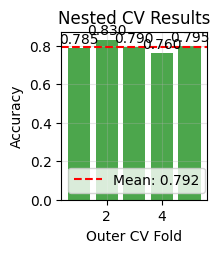

In [41]:
# Plot 4: Nested CV Visualization
plt.subplot(2, 3, 4)
fold_indices = np.arange(1, len(nested_scores) + 1)
bars = plt.bar(fold_indices, nested_scores, alpha=0.7, color='green')
plt.axhline(y=nested_scores.mean(), color='red', linestyle='--',
           label=f'Mean: {nested_scores.mean():.3f}')

plt.xlabel('Outer CV Fold')
plt.ylabel('Accuracy')
plt.title('Nested CV Results')
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels
for bar, score in zip(bars, nested_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')


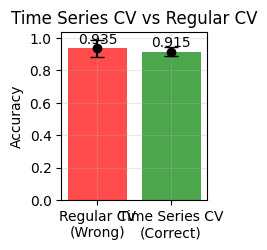

In [42]:
# Plot 5: Time Series CV Illustration
plt.subplot(2, 3, 5)
comparison_data = ['Regular CV\n(Wrong)', 'Time Series CV\n(Correct)']
ts_comparison_scores = [regular_scores.mean(), ts_scores.mean()]
colors = ['red', 'green']

bars = plt.bar(comparison_data, ts_comparison_scores, color=colors, alpha=0.7)
plt.ylabel('Accuracy')
plt.title('Time Series CV vs Regular CV')
plt.grid(True, alpha=0.3)

# Add value labels and error bars
plt.errorbar(comparison_data, ts_comparison_scores,
            yerr=[regular_scores.std(), ts_scores.std()],
            fmt='o', color='black', capsize=5)

for bar, score in zip(bars, ts_comparison_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')


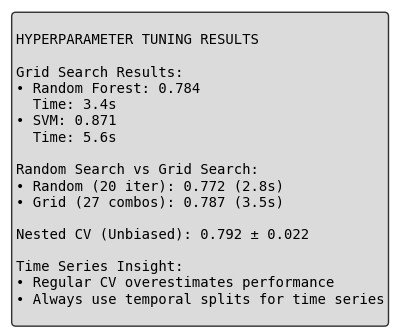


=== CROSS-VALIDATION & HYPERPARAMETER TUNING SUMMARY ===
Key Insights:


In [43]:
# Plot 6: Hyperparameter Tuning Summary
plt.subplot(2, 3, 6)
plt.axis('off')

summary_text = f"""
HYPERPARAMETER TUNING RESULTS

Grid Search Results:
• Random Forest: {grid_search_results['Random Forest']['best_score']:.3f}
  Time: {grid_search_results['Random Forest']['time_taken']:.1f}s
• SVM: {grid_search_results['SVM']['best_score']:.3f}
  Time: {grid_search_results['SVM']['time_taken']:.1f}s

Random Search vs Grid Search:
• Random (20 iter): {random_search.best_score_:.3f} ({random_time:.1f}s)
• Grid (27 combos): {grid_search_rf.best_score_:.3f} ({grid_time:.1f}s)

Nested CV (Unbiased): {nested_scores.mean():.3f} ± {nested_scores.std():.3f}

Time Series Insight:
• Regular CV overestimates performance
• Always use temporal splits for time series
"""

plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n=== CROSS-VALIDATION & HYPERPARAMETER TUNING SUMMARY ===")
print("Key Insights:")


In [44]:
# Best CV strategy
best_cv_method = max(cv_strategies.keys(),
                    key=lambda x: cv_results['Random Forest'][x]['mean']
                    if x != 'Leave-One-Out' else 0)
print(f"• Most stable CV method: {best_cv_method}")

# Search method comparison
if random_search.best_score_ > grid_search_rf.best_score_:
    better_search = "Random Search"
    worse_search = "Grid Search"
else:
    better_search = "Grid Search"
    worse_search = "Random Search"

print(f"• {better_search} found better hyperparameters than {worse_search}")
print(f"• Random search was {grid_time/random_time:.1f}x faster than grid search")

print(f"• Nested CV provides unbiased estimate: {nested_scores.mean():.3f} ± {nested_scores.std():.3f}")
print(f"• Time series CV is more conservative: {ts_scores.mean():.3f} vs {regular_scores.mean():.3f}")

print("\nBest Practices Demonstrated:")
print("• Use stratified CV for classification")
print("• Random search often more efficient than grid search")
print("• Nested CV provides unbiased model selection")
print("• Time series requires temporal CV splits")
print("• Validation curves help identify optimal hyperparameters")
print("• Always separate hyperparameter tuning from final evaluation")

print("\nCritical Reminders:")
print("• Never use test set for hyperparameter tuning")
print("• Apply preprocessing within each CV fold")
print("• Choose CV strategy based on data characteristics")
print("• Consider computational cost vs performance gain")
print("• Report confidence intervals for robust comparisons")

• Most stable CV method: K-Fold (k=10)
• Grid Search found better hyperparameters than Random Search
• Random search was 1.2x faster than grid search
• Nested CV provides unbiased estimate: 0.792 ± 0.022
• Time series CV is more conservative: 0.915 vs 0.935

Best Practices Demonstrated:
• Use stratified CV for classification
• Random search often more efficient than grid search
• Nested CV provides unbiased model selection
• Time series requires temporal CV splits
• Validation curves help identify optimal hyperparameters
• Always separate hyperparameter tuning from final evaluation

Critical Reminders:
• Never use test set for hyperparameter tuning
• Apply preprocessing within each CV fold
• Choose CV strategy based on data characteristics
• Consider computational cost vs performance gain
• Report confidence intervals for robust comparisons


## CROSS-VALIDATION & HYPERPARAMETER TUNING DEMO

## Practice Exercises

Now it's your turn! These exercises will help you practice what you've learned.


### Exercise 1: Your First Cross-Validation (Beginner)

**Task**: Create a simple dataset and perform 3-fold cross-validation

**Instructions**:
1. Create a classification dataset with 150 samples
2. Use a Decision Tree model
3. Perform 3-fold cross-validation
4. Print the scores for each fold

**Hints**:
- Use `make_classification()` to create data
- Use `KFold(n_splits=3, shuffle=True, random_state=42)`
- Use `cross_val_score()`

In [ ]:
# Write your code here!
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification

# Your code goes below:

### Exercise 2: Compare Different CV Strategies (Intermediate)

**Task**: Compare the results of 3-fold, 5-fold, and 10-fold cross-validation

**Instructions**:
1. Use the Iris dataset (built-in dataset)
2. Test with different numbers of folds: 3, 5, and 10
3. Compare the mean accuracy and standard deviation
4. Which one gives the most stable results?


In [ ]:
# Write your code here!
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier

# Your code goes below:

### Exercise 3: Grid Search Practice (Intermediate)

**Task**: Find the best hyperparameters for a Random Forest on the Iris dataset

**Instructions**:
1. Load the Iris dataset
2. Define a parameter grid with:
   - `n_estimators`: [10, 50, 100]
   - `max_depth`: [3, 5, None]
3. Use GridSearchCV with 5-fold cross-validation
4. Print the best parameters and best score


In [ ]:
# Write your code here!
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Your code goes below:

### Exercise 4: Random Search vs Grid Search (Advanced)

**Task**: Compare Grid Search and Random Search efficiency

**Instructions**:
1. Create a classification dataset with 500 samples
2. Set up both Grid Search and Random Search for a Random Forest
3. Measure the time each one takes
4. Compare the best scores found by each method
5. Which one is faster? Which one finds better parameters?


In [ ]:
# Write your code here!
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
import time

# Your code goes below:


### Exercise 5: Real-World Application Challenge (Advanced)

**Task**: Build a complete machine learning pipeline with proper validation

**Instructions**:
1. Load the breast cancer dataset (built-in)
2. Split data into train (80%) and test (20%) sets
3. Use Grid Search with 5-fold CV to find best parameters for Logistic Regression
4. Parameters to tune: `C`: [0.01, 0.1, 1, 10, 100]
5. Train final model with best parameters on full training set
6. Evaluate on test set
7. Compare: GridSearch CV score vs final test score


In [ ]:
# Write your code here!
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

# Your code goes below:

### 💡 Bonus Challenge: Nested Cross-Validation (Expert)

**Task**: Implement nested cross-validation to get an unbiased estimate

**Instructions**:
1. Use the wine dataset (built-in)
2. Implement 5-fold nested cross-validation
3. Inner loop: Grid search for hyperparameter tuning (3-fold CV)
4. Outer loop: Performance evaluation (5-fold CV)
5. Compare the nested CV score with simple Grid Search CV score
6. Which one do you trust more and why?


In [ ]:
# Write your code here!
from sklearn.datasets import load_wine
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.svm import SVC

# Your code goes below:

In [8]:
# Cross-Validation & Hyperparameter Tuning Comprehensive Demo
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, KFold, LeaveOneOut,
    GridSearchCV, RandomizedSearchCV, validation_curve,
    TimeSeriesSplit, GroupKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
import time

print("=== CROSS-VALIDATION & HYPERPARAMETER TUNING DEMO ===")

=== CROSS-VALIDATION & HYPERPARAMETER TUNING DEMO ===


In [9]:
# Generate dataset for demonstrations
X_cv, y_cv = make_classification(
    n_samples=1000, n_features=20, n_informative=15, n_redundant=5,
    n_classes=3, random_state=42
)

print(f"Dataset shape: {X_cv.shape}")
print(f"Classes distribution: {np.bincount(y_cv)}")


Dataset shape: (1000, 20)
Classes distribution: [333 331 336]


In [10]:
# Demo 1: Different Cross-Validation Strategies
print("\n=== CROSS-VALIDATION STRATEGIES COMPARISON ===")

# Create models for comparison
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'SVM': SVC(random_state=42)
}


=== CROSS-VALIDATION STRATEGIES COMPARISON ===


In [11]:
# Different CV strategies
cv_strategies = {
    'K-Fold (k=5)': KFold(n_splits=5, shuffle=True, random_state=42),
    'Stratified K-Fold (k=5)': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'K-Fold (k=10)': KFold(n_splits=10, shuffle=True, random_state=42),
    'Leave-One-Out': LeaveOneOut() if len(X_cv) <= 200 else StratifiedKFold(n_splits=min(len(X_cv)//10, 20), shuffle=True, random_state=42)
}


In [12]:
# Note: Using subset for LOOCV due to computational constraints
if len(X_cv) > 200:
    print("Note: Using subset for LOOCV demonstration due to computational constraints")
    X_loocv, y_loocv = X_cv[:200], y_cv[:200]
    cv_strategies['Leave-One-Out'] = LeaveOneOut()
else:
    X_loocv, y_loocv = X_cv, y_cv

cv_results = {}

for model_name, model in models.items():
    cv_results[model_name] = {}
    print(f"\n{model_name} Results:")

    for cv_name, cv_strategy in cv_strategies.items():
        if cv_name == 'Leave-One-Out':
            # Use smaller dataset for LOOCV
            scores = cross_val_score(model, X_loocv, y_loocv, cv=cv_strategy, scoring='accuracy')
        else:
            scores = cross_val_score(model, X_cv, y_cv, cv=cv_strategy, scoring='accuracy')

        cv_results[model_name][cv_name] = {
            'mean': scores.mean(),
            'std': scores.std(),
            'scores': scores
        }

        print(f"  {cv_name:>20}: {scores.mean():.3f} ± {scores.std():.3f}")


Note: Using subset for LOOCV demonstration due to computational constraints

Logistic Regression Results:
          K-Fold (k=5): 0.687 ± 0.022
  Stratified K-Fold (k=5): 0.676 ± 0.008
         K-Fold (k=10): 0.684 ± 0.050
         Leave-One-Out: 0.595 ± 0.491

Random Forest Results:
          K-Fold (k=5): 0.781 ± 0.025
  Stratified K-Fold (k=5): 0.783 ± 0.031
         K-Fold (k=10): 0.786 ± 0.029
         Leave-One-Out: 0.660 ± 0.474

SVM Results:
          K-Fold (k=5): 0.831 ± 0.025
  Stratified K-Fold (k=5): 0.835 ± 0.009
         K-Fold (k=10): 0.845 ± 0.040
         Leave-One-Out: 0.785 ± 0.411


In [13]:
# Demo 2: Grid Search Hyperparameter Tuning
print("\n=== GRID SEARCH HYPERPARAMETER TUNING ===")

# Define parameter grids
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']  # Supports both l1 and l2
    }
}


=== GRID SEARCH HYPERPARAMETER TUNING ===


In [14]:
grid_search_results = {}

for model_name in ['Random Forest', 'SVM']:  # Skip LogReg for time
    print(f"\nGrid Search for {model_name}:")

    if model_name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=42)
        param_grid = param_grids[model_name]
        # Reduce grid size for demo
        param_grid = {
            'n_estimators': [50, 100],
            'max_depth': [3, 5, None],
            'min_samples_split': [2, 5]
        }
    else:  # SVM
        base_model = SVC(random_state=42)
        param_grid = param_grids[model_name]
        # Reduce grid size for demo
        param_grid = {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 0.01, 0.1],
            'kernel': ['rbf', 'linear']
        }

    start_time = time.time()
    grid_search = GridSearchCV(
        base_model, param_grid, cv=5, scoring='accuracy',
        n_jobs=-1, return_train_score=True
    )
    grid_search.fit(X_cv, y_cv)
    end_time = time.time()

    grid_search_results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'time_taken': end_time - start_time,
        'n_combinations': len(grid_search.cv_results_['mean_test_score'])
    }

    print(f"  Best parameters: {grid_search.best_params_}")
    print(f"  Best CV score: {grid_search.best_score_:.3f}")
    print(f"  Total combinations tested: {len(grid_search.cv_results_['mean_test_score'])}")
    print(f"  Time taken: {end_time - start_time:.2f} seconds")



Grid Search for Random Forest:
  Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV score: 0.784
  Total combinations tested: 12
  Time taken: 3.41 seconds

Grid Search for SVM:
  Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV score: 0.871
  Total combinations tested: 18
  Time taken: 6.48 seconds


In [15]:
# Demo 3: Random Search vs Grid Search Comparison
print("\n=== RANDOM SEARCH VS GRID SEARCH COMPARISON ===")

# Focus on Random Forest for detailed comparison
rf_param_dist = {
    'n_estimators': randint(10, 200),
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

# Grid search (smaller grid)
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 7, None],
    'min_samples_split': [2, 5, 10]
}

# Random search
print("Random Search:")
start_time = time.time()
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), rf_param_dist,
    n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42
)
random_search.fit(X_cv, y_cv)
random_time = time.time() - start_time

print(f"  Best parameters: {random_search.best_params_}")
print(f"  Best CV score: {random_search.best_score_:.3f}")
print(f"  Time taken: {random_time:.2f} seconds")
print(f"  Combinations tested: 20")

# Grid search
print("\nGrid Search (reduced grid):")
start_time = time.time()
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42), rf_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_search_rf.fit(X_cv, y_cv)
grid_time = time.time() - start_time

print(f"  Best parameters: {grid_search_rf.best_params_}")
print(f"  Best CV score: {grid_search_rf.best_score_:.3f}")
print(f"  Time taken: {grid_time:.2f} seconds")
print(f"  Combinations tested: {len(grid_search_rf.cv_results_['mean_test_score'])}")



=== RANDOM SEARCH VS GRID SEARCH COMPARISON ===
Random Search:
  Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 60}
  Best CV score: 0.772
  Time taken: 3.19 seconds
  Combinations tested: 20

Grid Search (reduced grid):
  Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
  Best CV score: 0.787
  Time taken: 4.30 seconds
  Combinations tested: 27


In [16]:
# Demo 4: Nested Cross-Validation
print("\n=== NESTED CROSS-VALIDATION DEMO ===")

def nested_cv_score(model, param_grid, X, y, outer_cv=5, inner_cv=3):
    """
    Perform nested cross-validation for unbiased model evaluation
    """
    outer_scores = []
    outer_cv_splitter = StratifiedKFold(n_splits=outer_cv, shuffle=True, random_state=42)

    for train_idx, test_idx in outer_cv_splitter.split(X, y):
        X_train_outer, X_test_outer = X[train_idx], X[test_idx]
        y_train_outer, y_test_outer = y[train_idx], y[test_idx]

        # Inner CV for hyperparameter tuning
        inner_cv_splitter = StratifiedKFold(n_splits=inner_cv, shuffle=True, random_state=42)
        grid_search = GridSearchCV(
            model, param_grid, cv=inner_cv_splitter,
            scoring='accuracy', n_jobs=-1
        )
        grid_search.fit(X_train_outer, y_train_outer)

        # Evaluate best model on outer test set
        best_model = grid_search.best_estimator_
        outer_score = best_model.score(X_test_outer, y_test_outer)
        outer_scores.append(outer_score)

    return np.array(outer_scores)

# Perform nested CV on Random Forest
nested_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None]
}

print("Performing Nested Cross-Validation (may take a moment)...")
nested_scores = nested_cv_score(
    RandomForestClassifier(random_state=42),
    nested_param_grid, X_cv, y_cv
)

print(f"Nested CV Scores: {nested_scores}")
print(f"Mean nested CV score: {nested_scores.mean():.3f} ± {nested_scores.std():.3f}")
print(f"This represents unbiased estimate of model performance")



=== NESTED CROSS-VALIDATION DEMO ===
Performing Nested Cross-Validation (may take a moment)...
Nested CV Scores: [0.785 0.83  0.79  0.76  0.795]
Mean nested CV score: 0.792 ± 0.022
This represents unbiased estimate of model performance


In [17]:
# Demo 5: Validation Curves
print("\n=== VALIDATION CURVES ANALYSIS ===")

# Validation curve for Random Forest n_estimators
param_range = [10, 25, 50, 100, 150, 200]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42), X_cv, y_cv,
    param_name='n_estimators', param_range=param_range,
    cv=5, scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

print("Validation Curve Results (n_estimators):")
for i, n_est in enumerate(param_range):
    print(f"  n_estimators={n_est:3d}: Train={train_mean[i]:.3f}±{train_std[i]:.3f}, "
          f"Val={val_mean[i]:.3f}±{val_std[i]:.3f}")

# Demo 6: Time Series Cross-Validation
print("\n=== TIME SERIES CROSS-VALIDATION DEMO ===")

# Generate time series-like data
np.random.seed(42)
n_samples = 200
X_ts = np.random.randn(n_samples, 5)
# Add time dependency
for i in range(1, n_samples):
    X_ts[i, 0] += 0.5 * X_ts[i-1, 0]  # AR(1) process
y_ts = (X_ts[:, 0] + X_ts[:, 1] + np.random.randn(n_samples) * 0.1 > 0).astype(int)

print(f"Time series dataset shape: {X_ts.shape}")

# Compare regular CV vs Time Series CV
regular_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ts_cv = TimeSeriesSplit(n_splits=5)

model_ts = RandomForestClassifier(n_estimators=50, random_state=42)

# Regular CV (wrong for time series!)
regular_scores = cross_val_score(model_ts, X_ts, y_ts, cv=regular_cv)
print(f"Regular K-Fold CV (inappropriate): {regular_scores.mean():.3f} ± {regular_scores.std():.3f}")

# Time Series CV (correct approach)
ts_scores = cross_val_score(model_ts, X_ts, y_ts, cv=ts_cv)
print(f"Time Series CV (appropriate): {ts_scores.mean():.3f} ± {ts_scores.std():.3f}")

print("Note: Time Series CV typically gives more conservative estimates")



=== VALIDATION CURVES ANALYSIS ===
Validation Curve Results (n_estimators):
  n_estimators= 10: Train=0.990±0.004, Val=0.695±0.025
  n_estimators= 25: Train=1.000±0.000, Val=0.755±0.033
  n_estimators= 50: Train=1.000±0.000, Val=0.767±0.043
  n_estimators=100: Train=1.000±0.000, Val=0.784±0.032
  n_estimators=150: Train=1.000±0.000, Val=0.787±0.034
  n_estimators=200: Train=1.000±0.000, Val=0.789±0.033

=== TIME SERIES CROSS-VALIDATION DEMO ===
Time series dataset shape: (200, 5)
Regular K-Fold CV (inappropriate): 0.935 ± 0.051
Time Series CV (appropriate): 0.915 ± 0.030
Note: Time Series CV typically gives more conservative estimates


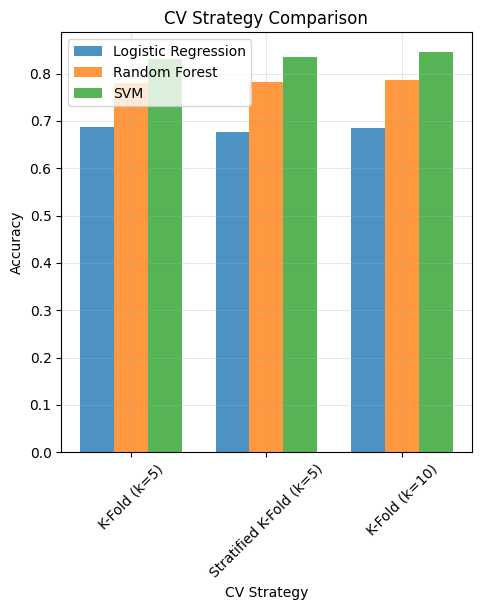

In [19]:
import matplotlib.pyplot as plt
# Visualization
plt.figure(figsize=(18, 12))

# Plot 1: CV Strategy Comparison
plt.subplot(2, 3, 1)
cv_methods = list(cv_strategies.keys())[:3]  # First 3 methods
lr_scores = [cv_results['Logistic Regression'][method]['mean'] for method in cv_methods]
rf_scores = [cv_results['Random Forest'][method]['mean'] for method in cv_methods]
svm_scores = [cv_results['SVM'][method]['mean'] for method in cv_methods]

x = np.arange(len(cv_methods))
width = 0.25

plt.bar(x - width, lr_scores, width, label='Logistic Regression', alpha=0.8)
plt.bar(x, rf_scores, width, label='Random Forest', alpha=0.8)
plt.bar(x + width, svm_scores, width, label='SVM', alpha=0.8)

plt.xlabel('CV Strategy')
plt.ylabel('Accuracy')
plt.title('CV Strategy Comparison')
plt.xticks(x, cv_methods, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)


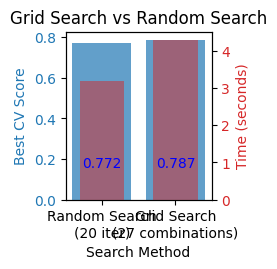

In [20]:
# Plot 2: Grid Search vs Random Search
plt.subplot(2, 3, 2)
methods = ['Random Search\n(20 iter)', 'Grid Search\n(27 combinations)']
scores = [random_search.best_score_, grid_search_rf.best_score_]
times = [random_time, grid_time]

fig_ax = plt.gca()
color = 'tab:blue'
fig_ax.set_xlabel('Search Method')
fig_ax.set_ylabel('Best CV Score', color=color)
bars1 = fig_ax.bar(methods, scores, color=color, alpha=0.7)
fig_ax.tick_params(axis='y', labelcolor=color)

# Add time on secondary y-axis
ax2 = fig_ax.twinx()
color = 'tab:red'
ax2.set_ylabel('Time (seconds)', color=color)
bars2 = ax2.bar(methods, times, color=color, alpha=0.5, width=0.6)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Grid Search vs Random Search')

# Add value labels
for bar, score in zip(bars1, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', color='blue')


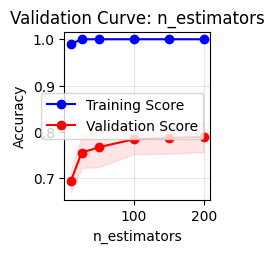

In [21]:
# Plot 3: Validation Curve
plt.subplot(2, 3, 3)
plt.plot(param_range, train_mean, 'o-', label='Training Score', color='blue')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(param_range, val_mean, 'o-', label='Validation Score', color='red')
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')

plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Validation Curve: n_estimators')
plt.legend()
plt.grid(True, alpha=0.3)


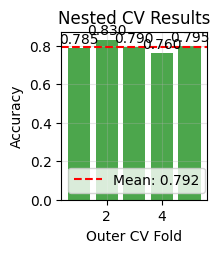

In [22]:
# Plot 4: Nested CV Visualization
plt.subplot(2, 3, 4)
fold_indices = np.arange(1, len(nested_scores) + 1)
bars = plt.bar(fold_indices, nested_scores, alpha=0.7, color='green')
plt.axhline(y=nested_scores.mean(), color='red', linestyle='--',
           label=f'Mean: {nested_scores.mean():.3f}')

plt.xlabel('Outer CV Fold')
plt.ylabel('Accuracy')
plt.title('Nested CV Results')
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels
for bar, score in zip(bars, nested_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

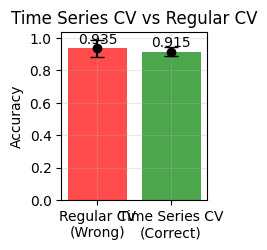

In [23]:
# Plot 5: Time Series CV Illustration
plt.subplot(2, 3, 5)
comparison_data = ['Regular CV\n(Wrong)', 'Time Series CV\n(Correct)']
ts_comparison_scores = [regular_scores.mean(), ts_scores.mean()]
colors = ['red', 'green']

bars = plt.bar(comparison_data, ts_comparison_scores, color=colors, alpha=0.7)
plt.ylabel('Accuracy')
plt.title('Time Series CV vs Regular CV')
plt.grid(True, alpha=0.3)

# Add value labels and error bars
plt.errorbar(comparison_data, ts_comparison_scores,
            yerr=[regular_scores.std(), ts_scores.std()],
            fmt='o', color='black', capsize=5)

for bar, score in zip(bars, ts_comparison_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')


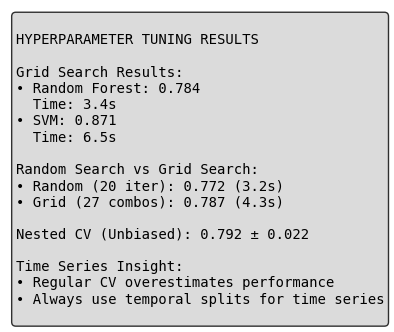


=== CROSS-VALIDATION & HYPERPARAMETER TUNING SUMMARY ===
Key Insights:


In [24]:
# Plot 6: Hyperparameter Tuning Summary
plt.subplot(2, 3, 6)
plt.axis('off')

summary_text = f"""
HYPERPARAMETER TUNING RESULTS

Grid Search Results:
• Random Forest: {grid_search_results['Random Forest']['best_score']:.3f}
  Time: {grid_search_results['Random Forest']['time_taken']:.1f}s
• SVM: {grid_search_results['SVM']['best_score']:.3f}
  Time: {grid_search_results['SVM']['time_taken']:.1f}s

Random Search vs Grid Search:
• Random (20 iter): {random_search.best_score_:.3f} ({random_time:.1f}s)
• Grid (27 combos): {grid_search_rf.best_score_:.3f} ({grid_time:.1f}s)

Nested CV (Unbiased): {nested_scores.mean():.3f} ± {nested_scores.std():.3f}

Time Series Insight:
• Regular CV overestimates performance
• Always use temporal splits for time series
"""

plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n=== CROSS-VALIDATION & HYPERPARAMETER TUNING SUMMARY ===")
print("Key Insights:")


In [25]:
# Best CV strategy
best_cv_method = max(cv_strategies.keys(),
                    key=lambda x: cv_results['Random Forest'][x]['mean']
                    if x != 'Leave-One-Out' else 0)
print(f"• Most stable CV method: {best_cv_method}")

# Search method comparison
if random_search.best_score_ > grid_search_rf.best_score_:
    better_search = "Random Search"
    worse_search = "Grid Search"
else:
    better_search = "Grid Search"
    worse_search = "Random Search"

print(f"• {better_search} found better hyperparameters than {worse_search}")
print(f"• Random search was {grid_time/random_time:.1f}x faster than grid search")

print(f"• Nested CV provides unbiased estimate: {nested_scores.mean():.3f} ± {nested_scores.std():.3f}")
print(f"• Time series CV is more conservative: {ts_scores.mean():.3f} vs {regular_scores.mean():.3f}")

print("\nBest Practices Demonstrated:")
print("• Use stratified CV for classification")
print("• Random search often more efficient than grid search")
print("• Nested CV provides unbiased model selection")
print("• Time series requires temporal CV splits")
print("• Validation curves help identify optimal hyperparameters")
print("• Always separate hyperparameter tuning from final evaluation")

print("\nCritical Reminders:")
print("• Never use test set for hyperparameter tuning")
print("• Apply preprocessing within each CV fold")
print("• Choose CV strategy based on data characteristics")
print("• Consider computational cost vs performance gain")
print("• Report confidence intervals for robust comparisons")

• Most stable CV method: K-Fold (k=10)
• Grid Search found better hyperparameters than Random Search
• Random search was 1.3x faster than grid search
• Nested CV provides unbiased estimate: 0.792 ± 0.022
• Time series CV is more conservative: 0.915 vs 0.935

Best Practices Demonstrated:
• Use stratified CV for classification
• Random search often more efficient than grid search
• Nested CV provides unbiased model selection
• Time series requires temporal CV splits
• Validation curves help identify optimal hyperparameters
• Always separate hyperparameter tuning from final evaluation

Critical Reminders:
• Never use test set for hyperparameter tuning
• Apply preprocessing within each CV fold
• Choose CV strategy based on data characteristics
• Consider computational cost vs performance gain
• Report confidence intervals for robust comparisons


---

## ✅ Exercise Solutions

### Solution 1: Your First Cross-Validation

```python
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
import numpy as np

# Create dataset
X, y = make_classification(n_samples=150, n_features=5, n_classes=2, random_state=42)

# Create model
model = DecisionTreeClassifier(random_state=42)

# Set up 3-fold CV
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

# Perform cross-validation
scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

# Print results
print("3-Fold Cross-Validation Results:")
for i, score in enumerate(scores, 1):
    print(f"Fold {i}: {score*100:.2f}%")
print(f"\nAverage: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")
```

### Solution 2: Compare Different CV Strategies

```python
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Create model
model = RandomForestClassifier(n_estimators=50, random_state=42)

# Test different numbers of folds
folds = [3, 5, 10]

print("Comparison of Different K-Fold Strategies:")
print("-" * 50)

for k in folds:
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    print(f"{k}-Fold CV: Mean = {scores.mean()*100:.2f}%, Std = {scores.std()*100:.2f}%")

print("\nConclusion: Higher k usually gives more stable estimates (lower std)")
```

### Solution 3: Grid Search Practice

```python
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Create model
model = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [3, 5, None]
}

# Perform grid search
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X, y)

# Print results
print("Grid Search Results:")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_*100:.2f}%")
print(f"Total combinations tested: {len(grid_search.cv_results_['mean_test_score'])}")
```

### Solution 4: Random Search vs Grid Search

```python
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
import time

# Create dataset
X, y = make_classification(n_samples=500, n_features=20, random_state=42)

# Grid search setup
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

# Random search setup
param_distributions = {
    'n_estimators': randint(10, 200),
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': randint(2, 20)
}

# Grid Search
print("Grid Search:")
start = time.time()
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid.fit(X, y)
grid_time = time.time() - start
print(f"  Best Score: {grid.best_score_*100:.2f}%")
print(f"  Time: {grid_time:.2f} seconds")
print(f"  Combinations: {len(grid.cv_results_['mean_test_score'])}")

# Random Search
print("\nRandom Search (20 iterations):")
start = time.time()
random = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions, 
                           n_iter=20, cv=5, n_jobs=-1, random_state=42)
random.fit(X, y)
random_time = time.time() - start
print(f"  Best Score: {random.best_score_*100:.2f}%")
print(f"  Time: {random_time:.2f} seconds")
print(f"  Combinations: 20")

print(f"\nRandom Search was {grid_time/random_time:.1f}x faster!")
```

### Solution 5: Real-World Application Challenge

```python
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Grid search
grid_search = GridSearchCV(LogisticRegression(max_iter=10000, random_state=42), 
                          param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Train final model
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)

# Results
print("Results:")
print(f"Best Parameter (C): {grid_search.best_params_['C']}")
print(f"Grid Search CV Score: {grid_search.best_score_*100:.2f}%")
print(f"Final Test Score: {test_score*100:.2f}%")
print(f"\nDifference: {abs(grid_search.best_score_ - test_score)*100:.2f}%")
```

### Solution 6: Nested Cross-Validation (Bonus)

```python
from sklearn.datasets import load_wine
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
import numpy as np

# Load data
wine = load_wine()
X, y = wine.data, wine.target

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1]
}

# Simple Grid Search (biased estimate)
simple_grid = GridSearchCV(SVC(random_state=42), param_grid, cv=3, n_jobs=-1)
simple_grid.fit(X, y)
simple_score = simple_grid.best_score_

# Nested Cross-Validation (unbiased estimate)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nested_scores = []

for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Inner CV for hyperparameter tuning
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid = GridSearchCV(SVC(random_state=42), param_grid, cv=inner_cv, n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Evaluate on outer test set
    score = grid.best_estimator_.score(X_test, y_test)
    nested_scores.append(score)

nested_scores = np.array(nested_scores)

print("Comparison:")
print(f"Simple Grid Search CV: {simple_score*100:.2f}%")
print(f"Nested CV: {nested_scores.mean()*100:.2f}% ± {nested_scores.std()*100:.2f}%")
print("\nNested CV is more trustworthy because:")
print("- It separates hyperparameter tuning from evaluation")
print("- Provides unbiased estimate of true performance")
print("- Simple Grid Search can be overly optimistic")
```